<a href="https://colab.research.google.com/github/PTRWNG-wzl/deep-learning-course/blob/master/05_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recurrent Neural Networks

A Recurrent Neural Network (RNN) is a specific type of architecture that is widely used to deal with sequential information. So far, the introduced CNN architectures from the previous tutorials treated inputs as independent objects, however, many applications need to deal with data that is interconnected. For instance, if you are translating a sentence from English to Taiwanese, and you are predicting the next word, it is useful to know which words came before the last one.

RNNs are called recurrent since they apply the same operation to each of the input sequences, with the output of an individual element being dependent on the previous one. Theoretically, RNNs establish a connection between the actual input and ALL the previous ones. Although this is assumed, in the practice, RNNs have proven to only *remember* a limited number of inputs. In other words, RNNs have a *memory* that allows them to *remember* previous elements and use their information to deal with the current input.

RNNs can be split into multiple types depending on their applications. For instance, if we want to predict one word given only the previous one, the topology of our network is a *One to One*. Another example is image captioning, where we can design a *One to Many* architecture to obtain a description from a single input image. The following diagram shows the different types of problems we can face ([Source](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)):


![alt text](http://karpathy.github.io/assets/rnn/diags.jpeg)

**A Closer Look to RNN**

The figure below shows the simplest version of an RNN, which can be easily derived from a simple feedforward architecture by adding a single loop:

![alt text](https://i.ibb.co/qnGH6RT/vanilla-rnn.png)

During training, the hidden state $h$ is iteratively updated based on the input value $x$ and the learned weights $W_h$ and $W_x$. The final output $y$ is estimated from the current state $h_t$ and the matrix $W_y$.

Although RNN can assure short-term dependencies within the network, simple RNNs become unable to learn to connect information as the gap between past and present information grows. To overcome this limitation, in practical applications LSTM unit is adopted, that is a special RNNs architecture composed of multiple interacting layers ([Source](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)):
![alt text](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png)



In this tutorial, we will use LSTMs straight away as a black box.

In [ ]:
!pip install wget
!pip install torchinfo

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=b3fda90302553ccd835f1a1ef49201d15d9c430ff39eb74fd332e74fa6a2835d
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
from collections import Counter
import io
import math
import os
import requests
import sys
import string
import time
import torch
import datasets
import copy

from IPython.display import SVG
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
import numpy as np
import pandas as pd
import sklearn
import tarfile
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import transformers
from datasets import load_dataset
import wget
import torch.nn.functional as F
import torchinfo

import nltk
nltk.download('punkt_tab')


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def set_seed(seed: int) -> None:
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    num_epochs: int = 10,
    val_loader: DataLoader = None,
    device: torch.device = DEVICE,
    verbose: bool = True,
):
    model = model.to(DEVICE)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
        train_loss /= len(train_loader.dataset)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x, y in val_loader:
                    x, y = x.to(device), y.to(device)
                    y_pred = model(x)
                    loss = criterion(y_pred, y)
                    val_loss += loss.item() * x.size(0)
            val_loss /= len(val_loader.dataset)
            if verbose:
                print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        else:
            if verbose:
                print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# ***Many to One* RNNs - Regression**

In this section, we are going to implement an easy example of an RNN in PyTorch. Given the records of a local newspaper, which indicates the number of new subscriptions per month, we want to predict the number of members that will join next month.

First, we load the data with the utility method in Pandas `read_csv`, which allows us to load directly the dataset from an URL address. Let's print some rows of the imported record to see the format of the data.

In [ ]:
data = pd.read_csv("https://drive.google.com/uc?id=1Hv2nuwVXO_aZN89llGva0hSH6k3kKAVm",usecols=[1],engine = "python")
data.head()

,Number of subscriptions to city newspaper
0,112
1,118
2,132
3,129
4,121


Moreover, let's plot the number of subscriptions per month.

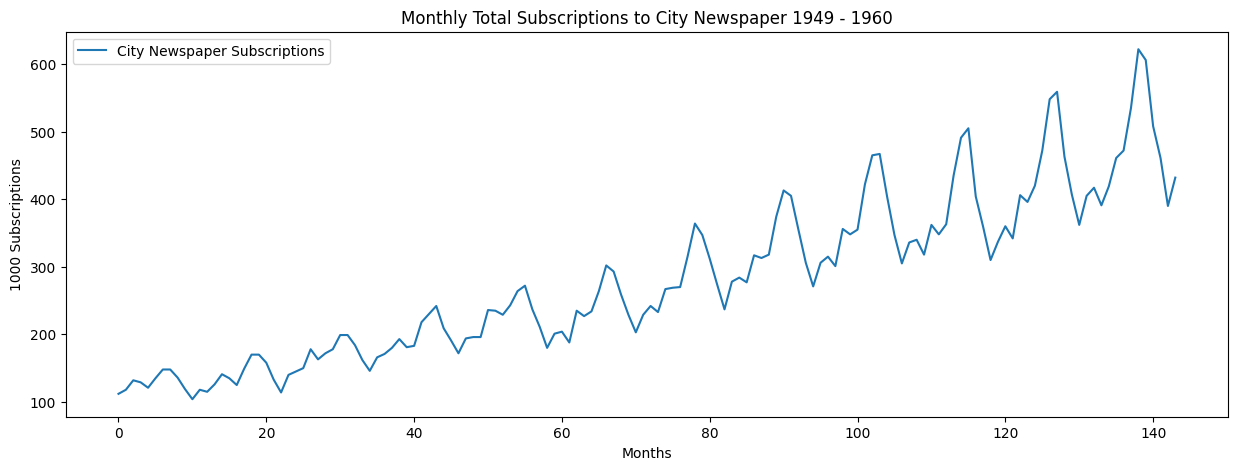

In [ ]:
plt.figure(figsize = (15, 5))
plt.plot(data, label = "City Newspaper Subscriptions")
plt.xlabel("Months")
plt.ylabel("1000 Subscriptions")
plt.title("Monthly Total Subscriptions to City Newspaper 1949 - 1960")
plt.legend()
plt.show()

First of all, we need to prepare the data for the training and test stage. Once the data is loaded, we normalize the input values and split them between training (70%) and testing (30%).


In [ ]:
# convert pandas data frame into a numpy array of float32
data_np = data.values.astype("float32")

# Split data into training and test using 70/30 split
TRAINING_PERC = 0.70
train_np = data_np[:int(len(data_np) * TRAINING_PERC), :]
test_np = data_np[int(len(data_np) * TRAINING_PERC):, :]

print("Number of samples training set:", len(train_np))
print("Number of samples test set:", len(test_np))

# Fit a MinMaxScaler only on the training data
normalizer = sklearn.preprocessing.MinMaxScaler(feature_range=(0, 1))
train_np_norm = normalizer.fit_transform(train_np)

# Use the same scaler to transform the test data
test_np_norm = normalizer.transform(test_np)

Number of samples training set: 100
Number of samples test set: 44


We also arrange the dataset (input and labels) in the appropriate PyTorch format by using the helper function `create_dataset()`.

`create_dataset()` takes as argument the variable `window_size`. This variable is highly important when dealing with sequences since it is going to determine the length of our input data to the network. For instance, by setting `window_size` to 5, we will be using the last 5 monthly subscriptions values to predict the next one.

In [ ]:
# helper function to read data
def create_dataset(dataset, window_size=1):
    X = [dataset[i:i+window_size, 0] for i in range(len(dataset) - window_size)]
    y = [dataset[i+window_size, 0] for i in range(len(dataset) - window_size)]
    return np.array(X), np.array(y)

# Create test and training sets for regression with window size 5
window_size = 5
train_X, train_Y = create_dataset(train_np_norm, window_size)
test_X, test_Y = create_dataset(test_np_norm, window_size)

# Add channel dimension (N, seq_len, 1)
train_X = np.expand_dims(train_X, -1)
test_X = np.expand_dims(test_X, -1)

# Convert to tensors
train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
train_Y_tensor = torch.tensor(train_Y, dtype=torch.float32).unsqueeze(1)  # (N, 1)

# Shapes
print(f"Shape of training inputs: {train_X_tensor.shape}")
print(f"Shape of training labels: {train_Y_tensor.shape}")

# Build a train data loader
train_dataset = TensorDataset(train_X_tensor, train_Y_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Shape of training inputs: torch.Size([95, 5, 1])
Shape of training labels: torch.Size([95, 1])


Once all the data is ready, we create the model as a `nn.Module` object including 16 LSTM units and a dense layer outputting a single scalar.
As mentioned, we specify a window size equal to 5, so that the prediction of the current element depends only on the previous five ones.

In [ ]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, output_size=1):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [ ]:
set_seed(42)

model = LSTMRegressor()
print(torchinfo.summary(model, input_size=(1, 5, 1)))

train(
    model,
    train_loader,
    nn.MSELoss(),
    optim.Adam(model.parameters(), lr=0.001),
    num_epochs=500,
    verbose=False,
)

Layer (type:depth-idx)                   Output Shape              Param #
LSTMRegressor                            [1, 1]                    --
├─LSTM: 1-1                              [1, 5, 16]                1,216
├─Linear: 1-2                            [1, 1]                    17
Total params: 1,233
Trainable params: 1,233
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01


Now we can compute the RMSE on the training and test data:

In [ ]:
def get_predict_and_score(model, X, Y, normalizer):
    model = model.to(DEVICE)
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        labels = torch.tensor(Y, dtype=torch.float32).unsqueeze(1).to(DEVICE)
        outputs = model(inputs)

        # Convert predictions and labels to NumPy
        pred = outputs.cpu().numpy()
        actual = labels.cpu().numpy()

        # Inverse transform both
        pred_inv = normalizer.inverse_transform(pred)
        actual_inv = normalizer.inverse_transform(actual)

        # Compute MSE
        rmse = math.sqrt(mean_squared_error(actual_inv, pred_inv))
        return rmse, pred_inv

rmse_train, train_predict = get_predict_and_score(model, train_X, train_Y, normalizer)
rmse_test, test_predict = get_predict_and_score(model, test_X, test_Y, normalizer)

print("Training RMSE: %.2f" % rmse_train)
print("Test RMSE: %.2f" % rmse_test)

Training RMSE: 21.79
Test RMSE: 63.07


Moreover, we can plot the predictions and actual values in a graph to check visually the performance of our predictor.

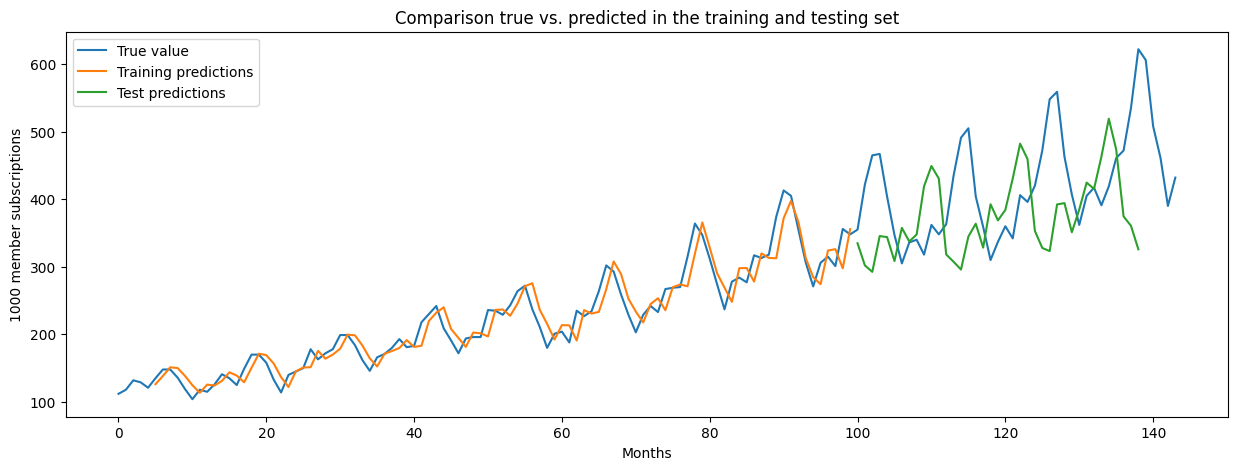

In [ ]:
# Training predictions placement
train_predictions = np.empty_like(data_np)
train_predictions[:] = np.nan
train_predictions[window_size:window_size + len(train_predict), :] = train_predict

# Test predictions placement
test_predictions = np.empty_like(data_np)
test_predictions[:] = np.nan
test_start = window_size + len(train_predict)
test_predictions[test_start:test_start + len(test_predict), :] = test_predict

# Create the plot.
plt.figure(figsize = (15, 5))
plt.plot(data_np, label = "True value") #transform back the full dataset
plt.plot(train_predictions, label = "Training predictions")
plt.plot(test_predictions, label = "Test predictions")
plt.xlabel("Months")
plt.ylabel("1000 member subscriptions")
plt.title("Comparison true vs. predicted in the training and testing set")
plt.legend()
plt.show()

#Sequence Modelling: Text

Now we will use RNNs to tackle text examples. Text is one of the modalities that have been widely tackled with deep learning improving upon past methods. We will present two problems: classification and generation.

A small summary of both problems is given below.

**Classification**

Classification is a standard problem, where we have some input data $x$ and try to classify it as one of the available classes $y$. In the case of sequential data, though, $x$ will be a sequence of elements that will be processed by the RNN to return the label $y$. The image depicts a sequence classification problem, where the red blocks are inputs, the green blocks the RNN model, and the blue block is the output. An example of a text classification problem that can be tackled with RNNs is "Hate speech detection", where the architecture must identify if an input text contains racist or sexist language, among others.

![alt text](https://i.ibb.co/TtZPpZr/Capture.jpg)


**Generation**

In a generation problem, we aim to generate a sequence $y$ following the same distribution as the real data $x$. We will input the sequence into the model, and we will output another sequence $y$. Text translation is a typical example of many to many RNNs.

![](https://i.ibb.co/7gSwnT2/Capture.jpg)



# Text Classification

For the text classification example we will use the IMDB movie reviews dataset available in Pytorch through the `torchtext` library. The dataset includes tens of thousands of movie reviews taken from the IMDB website with a corresponding label for each review. The label is binary, and indicates if the review has a positive (label=1) or negative (label=0) sentiment. This problem is a quite standard Natural Language Processing (NLP) problem, and it is called sentiment classification or sentiment analysis.

Before loading the data and building our model, we will explain a common part of NLP models, the embeddings.

### Embeddings
**References:**

[1] https://nlp.stanford.edu/projects/glove/

[2] https://colab.research.google.com/drive/1oXjNYSJ3VsRvAsXN4ClmtsVEgPW_CX_c?hl=en#scrollTo=p9q7qfXrvq-J


Usually, the first step of text modelling is transforming the words into a numerical vector that represents the meaning or some properties of the word. This vector can be then processed by the network. To do so, we first will encode the word sequences in integer numbers, and we will also have a dictionary that contains the relationship `(actual word, integer)`. For example, the sentence "the cat is on the table and the dog is on the mat" can be encoded in the form $(7, 1, 3, 5, 7, 6, 0, 7, 2, 3, 5, 7, 4)$, with the corresponding dictionary $(and, 0), (cat, 1), (dog, 2)\dots (the, 7)$:

In [ ]:
sentence = 'the cat is on the table and the dog is on the mat'
## We form a list of unique words by using a set
## which returns only unique elements
## we also sort them, which is not necessary
sentence_set = sorted(set(sentence.split(' ')))
words = list(sentence_set)
## We now form a dictionary in the form of
## e.g. dict_words[and] = 1
dict_words = dict((word, i) for i, word in enumerate(words))
## We now encode the sentence in a list of integers
encoded_sentence = [dict_words[w] for w in sentence.split()]
print("Sentence Set: ", sentence_set)
print("Vocabulary: ", encoded_sentence)
print("Encoded: ", dict_words)

Sentence Set:  ['and', 'cat', 'dog', 'is', 'mat', 'on', 'table', 'the']
Vocabulary:  [7, 1, 3, 5, 7, 6, 0, 7, 2, 3, 5, 7, 4]
Encoded:  {'and': 0, 'cat': 1, 'dog': 2, 'is': 3, 'mat': 4, 'on': 5, 'table': 6, 'the': 7}


PyTorch does not include a built-in tokenizer as part of its core API. Instead, tokenization and text preprocessing are typically handled manually or using external libraries such as `nltk`, `spacy`, or `torchtext`.

In this tutorial, we will use `nltk` to handle tokenization and build a vocabulary manually using Python collections. This allows us to convert raw text into numerical sequences that can be passed into neural network models. The process includes:

- Splitting raw text into tokens using `nltk.word_tokenize`
- Mapping each token to a unique integer ID using a `Counter`
- Padding sequences to uniform length for batching

You can read more about `nltk` and its tokenizers in the [NLTK documentation](https://www.nltk.org/api/nltk.tokenize.html).

In [ ]:
# First, we tokenize the input text using NLTK's word_tokenize.
# This splits the sentence into individual words (tokens).
# We also lowercase the text to ensure consistent vocabulary mapping.
tokens = nltk.word_tokenize(sentence.lower())
print("Tokens:", tokens)

Tokens: ['the', 'cat', 'is', 'on', 'the', 'table', 'and', 'the', 'dog', 'is', 'on', 'the', 'mat']


In [ ]:
## You can also check the word count
word_counts = Counter(tokens)
print("Word counts:", word_counts)

Word counts: Counter({'the': 4, 'is': 2, 'on': 2, 'cat': 1, 'table': 1, 'and': 1, 'dog': 1, 'mat': 1})


In [ ]:
## Now, the class has formed a dictionary with all the words
word_index = {word: idx + 1 for idx, (word, _) in enumerate(word_counts.items())}
print("Word index:", word_index)

Word index: {'the': 1, 'cat': 2, 'is': 3, 'on': 4, 'table': 5, 'and': 6, 'dog': 7, 'mat': 8}


In [ ]:
## You can transform the data to sequences of integers
## We print the first 10 elements
encoded_sequence = [word_index[token] for token in tokens]
print("Encoded sequence:", encoded_sequence)

Encoded sequence: [1, 2, 3, 4, 1, 5, 6, 1, 7, 3, 4, 1, 8]


Now that we have the sequence in the form of a list of integers,  we could input that directly to the RNN. However, as those numbers are arbitraryly chosen, it would be really hard for the RNN to understand the relationships between the words. To give the model more representation power, we first want to transform the integer to a vector of dimension $d$ which represents the semantic meaning of the words. Each of these vectors is called an Embedding. The actual values of the vectors are not important, only the relationships between them. For example, `dog` and `cat` vectors are probably going to be closer than `dog` and `the`. Or if you are doing sentiment classification, probably two words encoding similar positive sentiments will be closer than a word expressing positive sentiments and a completely neutral word.

 The embeddings can be initialized randomly and the model will learn suitable values to reduce the loss during the training process. However, embeddings which have already been trained in a large corpus of text such as Wikipedia can also be used. Examples of these pretrained embeddings are [Word2Vec](https://en.wikipedia.org/wiki/Word2vec) or  [GloVe](https://nlp.stanford.edu/projects/glove/). These methods are trained using the context of the words, for example predicting the surrounding words when a specific word is given. As a result, words that appear in similar contexts have closer embeddings.

![alt text](https://i.ibb.co/s5sg6dZ/Screenshot-from-2019-02-08-15-13-41.png)

The image shows relationships between words in the embedding space.



We now download the GloVe pretrained vectors trained in Wikipedia and Gigaword. [Here](https://nlp.stanford.edu/projects/glove/) you have an overview of what GloVe is. We will see how the embeddings contain a semantic meaning that allows us to model semantic relationships.

In [ ]:
## Download and unzip glove pretrained embeddings
!wget https://imperialcollegelondon.box.com/shared/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt -O glove_vectors.txt

--2026-03-06 02:48:57--  https://imperialcollegelondon.box.com/shared/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt
Resolving imperialcollegelondon.box.com (imperialcollegelondon.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to imperialcollegelondon.box.com (imperialcollegelondon.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt [following]
--2026-03-06 02:48:57--  https://imperialcollegelondon.box.com/public/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt
Reusing existing connection to imperialcollegelondon.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://imperialcollegelondon.app.box.com/public/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt [following]
--2026-03-06 02:48:58--  https://imperialcollegelondon.app.box.com/public/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt
Resolving imperialcollegelondon.app.box.com (imperialc

The code below prints the first 5 lines of the imported `glove_vectors.txt` file.
The first line is a header indicating that the dataset contains 400,000 tokens, each represented by a 300-dimensional embedding vector.
The lines that follow contain the actual embeddings, where each line corresponds to a word or punctuation mark (e.g., `the`, `,`, `.`, `of`, etc.), followed by its associated vector.

In [ ]:
with open("glove_vectors.txt", "r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline())

400000 300

the 0.04656 0.21318 -0.0074364 -0.45854 -0.035639 0.23643 -0.28836 0.21521 -0.13486 -1.6413 -0.26091 0.032434 0.056621 -0.043296 -0.021672 0.22476 -0.075129 -0.067018 -0.14247 0.038825 -0.18951 0.29977 0.39305 0.17887 -0.17343 -0.21178 0.23617 -0.063681 -0.42318 -0.11661 0.093754 0.17296 -0.33073 0.49112 -0.68995 -0.092462 0.24742 -0.17991 0.097908 0.083118 0.15299 -0.27276 -0.038934 0.54453 0.53737 0.29105 -0.0073514 0.04788 -0.4076 -0.026759 0.17919 0.010977 -0.10963 -0.26395 0.07399 0.26236 -0.1508 0.34623 0.25758 0.11971 -0.037135 -0.071593 0.43898 -0.040764 0.016425 -0.4464 0.17197 0.046246 0.058639 0.041499 0.53948 0.52495 0.11361 -0.048315 -0.36385 0.18704 0.092761 -0.11129 -0.42085 0.13992 -0.39338 -0.067945 0.12188 0.16707 0.075169 -0.015529 -0.19499 0.19638 0.053194 0.2517 -0.34845 -0.10638 -0.34692 -0.19024 -0.2004 0.12154 -0.29208 0.023353 -0.11618 -0.35768 0.062304 0.35884 0.02906 0.0073005 0.0049482 -0.15048 -0.12313 0.19337 0.12173 0.44503 0.25147 0.10781 -0.

We will now load the GloVe embeddings into a `torch.nn.Embedding` layer to manipulate the embeddings. This piece of code takes some time to load, as the embeddings file is quite large.

In [ ]:
# Load GloVe vectors and build vocab and weight matrix
def load_glove_as_embedding_layer(glove_path, embedding_dim):
    vocab = {"<unk>": 0}
    vectors = [torch.zeros(embedding_dim)]  # <unk> embedding
    skipped = 0

    with open(glove_path, 'r', encoding='utf-8') as f:
        first_line = f.readline()
        if len(first_line.strip().split()) == 2:
            print(f"Skipping header: {first_line.strip()}")
        else:
            f.seek(0)

        for line in f:
            tokens = line.strip().split()
            word = tokens[0]
            vector = tokens[1:]

            if len(vector) != embedding_dim:
                skipped += 1
                continue

            try:
                vector_tensor = torch.tensor([float(val) for val in vector], dtype=torch.float32)
            except ValueError:
                skipped += 1
                continue

            vocab[word] = len(vectors)
            vectors.append(vector_tensor)

    if len(vectors) <= 1:
        raise RuntimeError("No valid embeddings loaded. Check the file formatting.")

    print(f"Loaded {len(vectors)-1} word vectors. Skipped {skipped} lines.")

    weight_matrix = torch.stack(vectors)
    embedding_layer = nn.Embedding.from_pretrained(weight_matrix, freeze=False)
    return vocab, embedding_layer

# Example usage
glove_path = "glove_vectors.txt"
vocab, embedding = load_glove_as_embedding_layer(glove_path, embedding_dim=300)

Skipping header: 400000 300
Loaded 400000 word vectors. Skipped 0 lines.


In [ ]:
## Helper function - get embedding by word
def get_vector(word):
    idx = vocab.get(word)
    if idx is None:
        raise ValueError(f"Word '{word}' not in vocabulary.")
    return embedding(torch.tensor(idx))

Now we will do some operations using the embeddings of the words. First, we will do some words arithmetics based on the embeddings, which it will show us that the words encode some semantic meaning. For example, the distance between words with similar semantic meaning but different genders is approximately fixed. Meaning that the vector resulting from doing $man - woman$ should be similar to $king - queen$, hence:

$king - queen \approx man - woman \rightarrow woman + king - man \approx queen$

We can check this using the method `most_similar` and the `positive` and `negative` arguments as following:



In [ ]:
## We can do word arithmetics.
## We look for the nearest neighbour of the vector resulting on doing
## the operation 'king' + 'woman' - 'man'

def perform_arithmetic(positive, negative, vocab, embedding, top_k=5):
    """
    Performs word vector arithmetic and finds the top_k most similar words,
    excluding any input words.

    Args:
        positive (list): Words to add.
        negative (list): Words to subtract.
        vocab (dict): Word-to-index dictionary.
        embedding (nn.Embedding): Embedding layer with preloaded GloVe vectors.
        top_k (int): Number of nearest neighbors to return.

    Returns:
        list: Top-k similar words excluding inputs.
    """
    device = embedding.weight.device  # Ensures computation matches embedding's device

    # Compute the target vector: sum(positive) - sum(negative)
    vector = sum(get_vector(w) for w in positive) - sum(get_vector(w) for w in negative)

    # Compute cosine similarities to all vocab vectors
    all_vectors = embedding.weight
    similarities = F.cosine_similarity(vector.unsqueeze(0), all_vectors)

    # Get most similar words
    top_k_ids = similarities.topk(top_k + len(positive) + len(negative)).indices
    inv_vocab = {idx: word for word, idx in vocab.items()}

    # Remove input words
    input_words = set(positive + negative)
    result = []
    for idx in top_k_ids:
        word = inv_vocab.get(idx.item())
        if word not in input_words:
            result.append(word)
        if len(result) == top_k:
            break

    return result

# Run the query
similar_words = perform_arithmetic(positive=["king", "woman"], negative=["man"], vocab=vocab, embedding=embedding)
print("Most similar words to king + woman - man:", similar_words)

Most similar words to king + woman - man: ['queen', 'monarch', 'throne', 'princess', 'mother']


In [ ]:
## Similar examples
## google + ios - apple
similar_words = perform_arithmetic(positive=["google", "ios"], negative=["apple"], vocab=vocab, embedding=embedding)
print("Most similar words to google + ios - apple:", similar_words)

Most similar words to google + ios - apple: ['android', 'apps', 'app', 'smartphones', 'facebook']


In [ ]:
## england + paris - france
similar_words = perform_arithmetic(positive=["england", "paris"], negative=["france"], vocab=vocab, embedding=embedding)
print("Most similar words to england + paris - france:", similar_words)

Most similar words to england + paris - france: ['london', 'manchester', 'birmingham', 'middlesex', 'liverpool']


In [ ]:
## We can also check the word that does not match the rest
## This is done by finding the word with the embedding vector furthest away from the mean
def doesnt_match(words):
    vectors = torch.stack([get_vector(w) for w in words])
    mean_vector = vectors.mean(dim=0)
    distances = F.cosine_similarity(vectors, mean_vector.unsqueeze(0))
    odd_one_index = distances.argmin().item()
    return words[odd_one_index]

print("Word that doesnt match from ['breakfast', 'cereal', 'dinner', 'lunch']: ",
      doesnt_match(['breakfast', 'cereal', 'dinner', 'lunch']))

Word that doesnt match from ['breakfast', 'cereal', 'dinner', 'lunch']:  cereal


In http://projector.tensorflow.org/ you can visualize the words projected in the $\mathbb{R}^3$ space using either PCA or tSNE, which are both techniques for dimensionality reduction. There, you can see how words are clustered by meaning or topic.


![](https://brenndoerfer.github.io/deep-sentiment-analysis-distill/img/tensorboard_projector.gif)

Image taken from [here](https://brenndoerfer.github.io/deep-sentiment-analysis-distill/index.html)

### IMDB
Now let's start tackling a text classification problem. We first load the IMDB dataset for sentiment classification. As we said, it contains movie reviews with a corresponding binary sentiment label (label=1 corresponds to positive sentiment, and label=0 to negative sentiment). The words are already encoded as integers in order from most common words to less common (e.g. `the` is a common word so it should be encoded as a small integer). That makes it easy to filter the non-common words by using the argument `num_words` when loading the data. The filtered words will be all encoded as a special token `<UNK>`, which means unknown. For example, if we want to load the dataset with only the top $5000$ most common words we can do this:

In [ ]:
from torch.nn.utils.rnn import pad_sequence

# Parameters
nb_words = 5000
maxlen = 80

# Load IMDb
dataset = load_dataset("imdb")

# Tokenizer
def tokenize(text):
    return nltk.word_tokenize(text.lower())

# 1. Build vocabulary from training set
counter = Counter()
for text in dataset['train']['text']:
    counter.update(tokenize(text))

# Reserve 0:<PAD>, 1:<START>, 2:<UNK>
most_common = counter.most_common(nb_words - 3)
word2idx = {'<PAD>': 0, '<START>': 1, '<UNK>': 2}
for idx, (word, _) in enumerate(most_common, start=3):
    word2idx[word] = idx
idx2word = {idx: word for word, idx in word2idx.items()}

# 2. Encode function
def encode(text):
    tokens = tokenize(text)
    indices = [word2idx.get(t, word2idx['<UNK>']) for t in tokens]
    return [word2idx['<START>']] + indices[:maxlen-1]

# 3. Preprocess dataset into fixed-size tensors
def preprocess(texts):
    encoded = [torch.tensor(encode(t), dtype=torch.long) for t in texts]
    padded = pad_sequence(encoded, batch_first=True, padding_value=word2idx['<PAD>'])
    # ensure exact maxlen
    if padded.size(1) < maxlen:
        pad_len = maxlen - padded.size(1)
        padded = torch.nn.functional.pad(padded, (0, pad_len), value=word2idx['<PAD>'])
    return padded[:, :maxlen]

# 4. Apply to IMDb
x_train = preprocess(dataset['train']['text'])
y_train = torch.tensor(dataset['train']['label'], dtype=torch.long)

x_test = preprocess(dataset['test']['text'])
y_test = torch.tensor(dataset['test']['label'], dtype=torch.long)

train_ds = TensorDataset(x_train, y_train)
test_ds = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

We see that the dataset contains 25000 examples for both train and testing. Let's print an example.

In [ ]:
print(x_train[0])

tensor([   1,   17, 1562,   17,  254,    2,   49,   71,  411, 1151,  103,    8,
          44,    3,    2,   19, 3317,   15,   65,   15,   21,  106,  638,   16,
           2,   17,  100,  557,   19,   43,  106,   15,   21,    2,   46, 2323,
           2,   59,   15,  141,  788,    9, 2488,   18,  692,    4, 1570,  129,
           7,  349,    8,  125, 1153,   34, 3066,   33,   17,   78,   80,    9,
          82,   18,   23,    2,   13,   14,   11,   12,   13,   14,   11,   12,
           3,  135,   10,    2,  204,    7,  201, 3835])


The printed example is a sequence of numbers. It is important to note that there are three special integers in this IMDB dataset: $0$, $1$ and $2$. $0$ will be used to pad the sequences, which we will explain now. $1$ is used as the `<START>` token (you can see how the printed sequence starts with a `1`). $2$ is the token `<UNK>` which is used for all the filtered non-common words. If we want to retrieve the actual sentence, we can use the method `word2idx()`.

In [ ]:
# Retrieve the first encoded sentence
encoded_sentence = x_train[0]

# Decode using idx2word
decoded_sentence = ' '.join([idx2word[idx.item()] for idx in encoded_sentence if idx.item() in idx2word])

print(decoded_sentence)
print(y_train[0].item())

<START> i rented i am <UNK> from my video store because of all the <UNK> that surrounded it when it was first released in <UNK> i also heard that at first it was <UNK> by u.s. <UNK> if it ever tried to enter this country , therefore being a fan of films considered `` controversial '' i really had to see this for <UNK> < br / > < br / > the plot is <UNK> around a young swedish
0


We can see how we just recovered the sentence that we had printed before as a sequence of numbers. The review is negative, so the corresponding label is "0".

One of the problems with the given text data is that the sequences all have a different length. We want to give PyTorch a batch of inputs with fixed dimensions. To do so, we define a maximum length `maxlen`, and truncate the sentences longer than that, and also pad with $0$'s at the beginning the sentences shorter than that length.

We use PyTorch’s `pad_sequence` utility from `torch.nn.utils.rnn`, along with `torch.nn.functional.pad`, to accomplish this.

We will now build the model we will use for sentiment classification. The model is formed by an Embedding layer, where the model will learn a vector of dimensionality `embedding_dim` for each of the words; an LSTM layer and a linear layer that maps the output of the LSTM to 1 value. We train this with the `binary_crossentropy` loss and `sigmoid` activation as we only have two classes.

In [ ]:
# Model Parameters
embedding_dim = 300
lstm_units = 128
vocab_size = nb_words

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, lstm_units):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=word2idx['<PAD>'])
        self.lstm = nn.LSTM(embedding_dim, lstm_units, batch_first=True)
        self.fc = nn.Linear(lstm_units, 1)

    def forward(self, x):
        x = self.embedding(x)                           # (batch, seq_len) -> (batch, seq_len, embed_dim)
        output, (h_n, c_n) = self.lstm(x)               # output: (batch, seq_len, hidden), h_n: (1, batch, hidden)
        last_hidden = h_n[-1]                           # (batch, hidden)
        out = self.fc(last_hidden)                      # (batch, 1)
        return torch.sigmoid(out).squeeze(1)            # (batch,)

# Instantiate the model
model = SentimentLSTM(vocab_size, embedding_dim, lstm_units).to(DEVICE)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

Let's train it for 5 epochs.

In [ ]:
from sklearn.metrics import accuracy_score

set_seed(42)

history = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': [],
    'epoch': []
}

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    train_losses = []
    all_preds = []
    all_labels = []

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE).float()
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        all_preds.extend((preds > 0.5).cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

    train_loss = sum(train_losses) / len(train_losses)
    train_acc = accuracy_score(all_labels, all_preds)

    # Validation
    model.eval()
    val_losses = []
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE).float()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)

            val_losses.append(loss.item())
            val_preds.extend((preds > 0.5).cpu().numpy())
            val_labels.extend(batch_y.cpu().numpy())

    val_loss = sum(val_losses) / len(val_losses)
    val_acc = accuracy_score(val_labels, val_preds)

    # Save to history
    history['epoch'].append(epoch)
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}  "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

Epoch 1/5  Train Loss: 0.6877, Acc: 0.5435  Val Loss: 0.6612, Acc: 0.6043
Epoch 2/5  Train Loss: 0.5925, Acc: 0.6886  Val Loss: 0.5470, Acc: 0.7290
Epoch 3/5  Train Loss: 0.4616, Acc: 0.7910  Val Loss: 0.4955, Acc: 0.7693
Epoch 4/5  Train Loss: 0.3768, Acc: 0.8388  Val Loss: 0.5102, Acc: 0.7672
Epoch 5/5  Train Loss: 0.2953, Acc: 0.8799  Val Loss: 0.4993, Acc: 0.7695


This is a classification example, so let's print the loss and the classification accuracy.

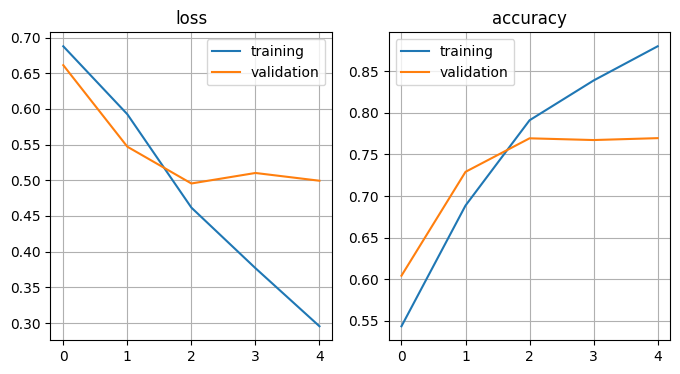

In [ ]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history['epoch'], history['loss'], label='training')
plt.plot(history['epoch'], history['val_loss'], label='validation')
plt.title('loss')
plt.grid(visible=True)
plt.legend(loc='best')

plt.subplot(1,2,2)
plt.plot(history['epoch'], history['accuracy'], label='training')
plt.plot(history['epoch'], history['val_accuracy'], label='validation')
plt.title('accuracy')
plt.grid(visible=True)
plt.legend(loc='best')

It looks like we could have stopped the training earlier as the validation loss keeps increasing after the first epoch.

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE).float()
        preds = model(batch_x)
        preds_binary = (preds > 0.5).cpu().numpy()
        all_preds.extend(preds_binary)
        all_labels.extend(batch_y.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Accuracy: 76.95%


### Saving best performing model

Now we save the best performing models using the validation loss as a metric. As you already know, lower training error does not mean in some cases better performance in the validation or test split.

In the last example we ran the model for 5 epochs, however after the first epoch the validation loss increased. We want to use the model performing the best in the validation set. To do so, we can use a ModelCheckpoint callback as was explained in past tutorials.

In [ ]:
import copy

set_seed(42)

# Re-instantiate model
embedding_dim = 300
lstm_units = 128
vocab_size = nb_words

model = SentimentLSTM(vocab_size, embedding_dim, lstm_units).to(DEVICE)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

initial_weight = model.fc.weight.clone()

# For tracking best validation loss
best_val_acc = 0
best_model_state = None
best_epoch = 0

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_losses = []
    all_preds = []
    all_labels = []

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE).float()
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        all_preds.extend((preds > 0.5).cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

    train_loss = sum(train_losses) / len(train_losses)
    train_acc = accuracy_score(all_labels, all_preds)

    # Validation
    model.eval()
    val_losses = []
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE).float()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)

            val_losses.append(loss.item())
            val_preds.extend((preds > 0.5).cpu().numpy())
            val_labels.extend(batch_y.cpu().numpy())

    val_loss = sum(val_losses) / len(val_losses)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        torch.save(best_model_state, 'best_model.pth')
        print("Saved best model")

print(f"Best model was from epoch {best_epoch} with val accuracy {best_val_acc:.4f}")

Epoch 1: Train Loss=0.6799, Train Acc=0.5639, Val Loss=0.6680, Val Acc=0.5977
Saved best model
Epoch 2: Train Loss=0.6026, Train Acc=0.6808, Val Loss=0.5982, Val Acc=0.7146
Saved best model
Epoch 3: Train Loss=0.4840, Train Acc=0.7762, Val Loss=0.5302, Val Acc=0.7348
Saved best model
Epoch 4: Train Loss=0.3867, Train Acc=0.8307, Val Loss=0.4954, Val Acc=0.7725
Saved best model
Epoch 5: Train Loss=0.3097, Train Acc=0.8722, Val Loss=0.5340, Val Acc=0.7707
Epoch 6: Train Loss=0.2389, Train Acc=0.9037, Val Loss=0.5671, Val Acc=0.7696
Epoch 7: Train Loss=0.1750, Train Acc=0.9343, Val Loss=0.6329, Val Acc=0.7716
Epoch 8: Train Loss=0.1216, Train Acc=0.9586, Val Loss=0.7235, Val Acc=0.7697
Epoch 9: Train Loss=0.0832, Train Acc=0.9733, Val Loss=0.7740, Val Acc=0.7632
Epoch 10: Train Loss=0.0597, Train Acc=0.9832, Val Loss=0.8767, Val Acc=0.7683
Best model was from epoch 4 with val accuracy 0.7725


We now saved the model after every epoch if the validation accuracy increased. In this case, the best epoch is the fourth one, so that version of the model is saved. Let's load the model now.

In [ ]:
# Load the best saved model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

SentimentLSTM(
  (embedding): Embedding(5000, 300, padding_idx=0)
  (lstm): LSTM(300, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

And now we check if the accuracy is better compared to when we used the model trained for 5 epochs.

In [ ]:
# Let's see the accuracy in the test split
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE).float()
        preds = model(batch_x)
        preds_binary = (preds > 0.5).cpu().numpy()
        all_preds.extend(preds_binary)
        all_labels.extend(batch_y.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Accuracy: 77.25%


### Importance of embeddings
Now, let's check quickly if using Embeddings provide any benefit. For this experiment, we remove the Embedding layer, meaning we will be inputting the word index, i.e. an integer, to the LSTM. Additionally, we need to vary the shape of the input data as the LSTM needs a third dimension with the number of channels per input (in this case 1, as each word is represented by an integer).

In [ ]:
# model parameters
# Same model as before but without embeddings
lstm_units = 128

# Reshape to (batch_size, seq_len, 1)
x_train_r = x_train.unsqueeze(-1).float()
x_test_r = x_test.unsqueeze(-1).float()

class LSTMNoEmbedding(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden.squeeze(0))
        return out

In [ ]:
# Use same labels
train_dataset = TensorDataset(x_train_r, y_train)
test_dataset = TensorDataset(x_test_r, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

In [ ]:
set_seed(42)

model = LSTMNoEmbedding(hidden_dim=128).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters())

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(5):
    model.train()
    train_loss, train_correct, total = 0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE).float()

        optimizer.zero_grad()
        output = model(xb).squeeze()
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * yb.size(0)
        preds = (torch.sigmoid(output) > 0.5).long()
        train_correct += (preds == yb.long()).sum().item()
        total += yb.size(0)

    avg_train_loss = train_loss / total
    avg_train_acc = train_correct / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE).float()
            output = model(xb).squeeze()
            loss = criterion(output, yb)

            val_loss += loss.item() * yb.size(0)
            preds = (torch.sigmoid(output) > 0.5).long()
            val_correct += (preds == yb.long()).sum().item()
            val_total += yb.size(0)

    avg_val_loss = val_loss / val_total
    avg_val_acc = val_correct / val_total

    history['loss'].append(avg_train_loss)
    history['accuracy'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_accuracy'].append(avg_val_acc)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={avg_train_acc:.4f}, Val Loss={avg_val_loss:.4f}, Val Acc={avg_val_acc:.4f}")


Epoch 1: Train Loss=0.6908, Train Acc=0.5276, Val Loss=0.6871, Val Acc=0.5495
Epoch 2: Train Loss=0.6872, Train Acc=0.5456, Val Loss=0.6869, Val Acc=0.5502
Epoch 3: Train Loss=0.6863, Train Acc=0.5494, Val Loss=0.6929, Val Acc=0.5339
Epoch 4: Train Loss=0.6862, Train Acc=0.5522, Val Loss=0.6867, Val Acc=0.5496
Epoch 5: Train Loss=0.6856, Train Acc=0.5528, Val Loss=0.6877, Val Acc=0.5478


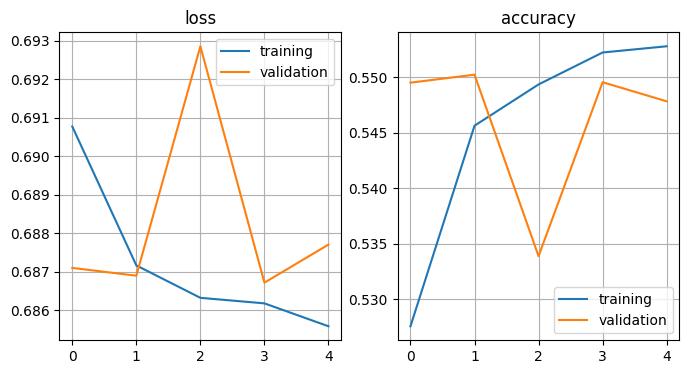

In [ ]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history['loss'], label='training')
plt.plot(history['val_loss'], label='validation')
plt.title('loss')
plt.grid(visible=True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['accuracy'], label='training')
plt.plot(history['val_accuracy'], label='validation')
plt.title('accuracy')
plt.grid(visible=True)
plt.legend();

We see how the accuracy is just slightly better compared to doing a random guess as there are only 2 classes. That is because the integer that encodes the word is chosen arbitrarily and does not encode any property of the words nor any relationship between words. Hence, using learned embeddings results in models with better capacity/accuracy for this kind of tasks.

Instead of inputting directly integers to the RNN, we could argue that another way of representing the input words is to input the one-hot representation of the word directly to the RNN instead of using embeddings. This method has two problems. First, the resulting dimensionality would be too large. In this case we are loading the $5000$ most common words in IMDB, so each word would be encoded in a vector of dimensionality $5000$. Secondly, the encoding does not give any notion of similarity between the different words. For these two reasons, embedding the words to a common lower dimensionality space is also better than using one-hot encoding.

# Text Generation

We now will present an example of text generation using an RNN. We will use the Tiny Shakespeare dataset, which contains samples from Shakespeare works.

We pose the problem as a classification problem as in the Sentiment classification example. In a text generation setting, given a sequence, we aim to predict the next one. During the training step, the process would be quite similar to the classification task, i.e. given a sequence you predict a label/word/character. However, in the prediction setting, we aim to output a whole sentence, not only a word or character. For that reason we will follow the procedure explained in the image.

![](https://cdn-images-1.medium.com/max/1600/1*XvUt5wDQA8D3C0wAuxAvbA.png)
The image is taken from [here](https://medium.com/@david.campion/text-generation-using-bidirectional-lstm-and-doc2vec-models-1-3-8979eb65cb3a)

As in the text classification section, we encode the raw sentences in the form of a sequence of integers. In this case, however, we have a text with a really wide vocabulary, and we aim to predict the following element of the sequence. In this dataset the number of words is really large, so if we used a word-level model the number of available classes would be quite large if we did not filter the number of possible words. For this example, instead of encoding on a word level, we will do it on a character level, which results in a more limited vocabulary. We aim to predict the next character when inputting a sentence of length $d$. In evaluation mode, i.e. when we are predicting the next character, we then input a seed of $d$ characters as the first input, and afterwards we use the last $d$ characters as input to predict the next character.

The advantages of predicting characters instead of words is that character-level models have a limited vocabulary/classes compared to the number of possible words in a text. They are also more flexible (for example, they can generate "fake" url links if trained in e.g. wikipedia data). However, word-level models usually present higher performance as it easier for them to keep track of the long-term meaning of the sentence, and also can avoid any spelling mistakes that may happen in character-level models.



We first download the data we use for the example, and then read the file.

In [ ]:
!wget https://raw.githubusercontent.com/jcjohnson/torch-rnn/master/data/tiny-shakespeare.txt
## We read all the raw data in the variable data
data = open('./tiny-shakespeare.txt', 'r').read()

--2026-03-06 02:52:17--  https://raw.githubusercontent.com/jcjohnson/torch-rnn/master/data/tiny-shakespeare.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘tiny-shakespeare.txt’

tiny-shakespeare.tx 100%[===================>]   1.06M  --.-KB/s    in 0.05s   

2026-03-06 02:52:17 (22.3 MB/s) - ‘tiny-shakespeare.txt’ saved [1115394/1115394]



Let's print a subset of the data for visualization purposes.

In [ ]:
print(data[:364])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?


We see in the raw text that the name of the characters is printed, that there is a blank line between the different character lines, and also that lines are usually not longer than ~80 characters. We hope the network is capable of learning all of this.

Now we will structure the data so we can input it into our RNN model. We aim to encode the text using a sequence of integers as we explained in the classification section.  Hence, we form a dictionary with all the different characters appearing in the text (including whitespaces and punctuation) and its corresponding integer.

In [ ]:
characters = sorted(list(set(data)))
n_to_char = {n:char for n, char in enumerate(characters)}
char_to_n = {char:n for n, char in enumerate(characters)}

Now we want to split the text in examples of length `seq_length` where the label is the next character. As we mentioned, we pose the problem as a set of successive classification problems, where we try to predict the next word given an input sentence. To split the text in pairs of (sequence, next word), we use the dictionary `char_to_n` to encode the different elements as integers.


In [ ]:
x = []
y = []
length = len(data)
seq_length = 100
for i in range(0, length-seq_length, 1):
  sequence = data[i:i + seq_length]
  label = data[i + seq_length]
  x.append([char_to_n[char] for char in sequence])
  y.append(char_to_n[label])
n_samples = len(x)
print("Total Samples: {:d}".format(n_samples))

Total Samples: 1115294


We now form a test split by using 5% of the available data. To do so, we just take the last 5% of the data. Usually, you need to randomize the data before splitting in test/train to avoid having a different distribution of the data in both splits. However, as this is a sequential data where we want to predict the next character, if we shuffle the splits we would have this in training:

``
x = 'the boy is tal_' y = 'l'
``

and this in testing:

``
x = 'the boy is ta_' y = 'l'
``

which would contaminate the splits.

In [ ]:
# train/test split
x_train = torch.tensor(x[:int(n_samples*0.95)], dtype=torch.long)
x_test  = torch.tensor(x[int(n_samples*0.95):], dtype=torch.long)
y_train = torch.tensor(y[:int(n_samples*0.95)], dtype=torch.long)
y_test  = torch.tensor(y[int(n_samples*0.95):], dtype=torch.long)

# reshape to (num_samples, seq_length)
x_train = x_train.view(len(x_train), seq_length)
x_test  = x_test.view(len(x_test), seq_length)

# one-hot encode labels
num_classes = len(characters)  # number of distinct characters
y_train = F.one_hot(y_train, num_classes=num_classes).float()
y_test  = F.one_hot(y_test,  num_classes=num_classes).float()

y_train_idx = y_train.argmax(dim=1)  # shape [N]
y_test_idx  = y_test.argmax(dim=1)   # shape [N]

Let's print a sequence and the shape of the labels.

In [ ]:
print(x_train[8000])
print(y_train_idx.shape)

tensor([ 0, 13,  1, 57, 47, 41, 49,  1, 51, 39, 52,  5, 57,  1, 39, 54, 54, 43,
        58, 47, 58, 43,  6,  1, 61, 46, 53,  1, 42, 43, 57, 47, 56, 43, 57,  1,
        51, 53, 57, 58,  1, 58, 46, 39, 58,  0, 35, 46, 47, 41, 46,  1, 61, 53,
        59, 50, 42,  1, 47, 52, 41, 56, 43, 39, 57, 43,  1, 46, 47, 57,  1, 43,
        60, 47, 50,  8,  1, 20, 43,  1, 58, 46, 39, 58,  1, 42, 43, 54, 43, 52,
        42, 57,  0, 33, 54, 53, 52,  1, 63, 53])
torch.Size([1059529])


Here, we define the model.

In [ ]:
class LSTMTextGen(nn.Module):
    def __init__(self, vocab_size, embedding_size, lstm_units):
        super(LSTMTextGen, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.lstm = nn.LSTM(embedding_size, lstm_units, batch_first=True)
        self.fc = nn.Linear(lstm_units, vocab_size)  # output = vocab size

    def forward(self, x):
        x = self.embedding(x)            # (B, T, E)
        out, _ = self.lstm(x)            # (B, T, H)
        last = out[:, -1, :]             # (B, H)
        logits = self.fc(last)           # (B, V)
        return logits

The model is a little bit complex, so training takes some time.

In [ ]:
set_seed(42)

train_loader = DataLoader(TensorDataset(x_train, y_train_idx), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(x_test,  y_test_idx),  batch_size=128, shuffle=False)

text_gen_model = LSTMTextGen(vocab_size=y_train.shape[1], embedding_size=100, lstm_units=128).to(DEVICE)

train(
    text_gen_model,
    train_loader,
    nn.CrossEntropyLoss(),
    torch.optim.Adam(text_gen_model.parameters(), lr=1e-3),
    num_epochs=10,
)

Epoch [1/10] Train Loss: 1.7973
Epoch [2/10] Train Loss: 1.5389
Epoch [3/10] Train Loss: 1.4744
Epoch [4/10] Train Loss: 1.4395
Epoch [5/10] Train Loss: 1.4158
Epoch [6/10] Train Loss: 1.3984
Epoch [7/10] Train Loss: 1.3851
Epoch [8/10] Train Loss: 1.3743
Epoch [9/10] Train Loss: 1.3655
Epoch [10/10] Train Loss: 1.3577


### Prediction

We now take any of the sequences from the test split and use it as an initial pattern for our model. Then we enter a loop where given an input sequence, we predict the next character and then form a new input sequence by appending the predicted character and dropping the first character.

Whenever we input a sequence, we obtain as output a probability distribution of the possible characters. For example, given the sequence `the cat and the do` the model will output a probability distribution of the next character where probably the character `g` will have a high probability (forming then `the cat and the dog`). However, the character `c` can also be a possibility, as the sentence formed may be `the cat and the doctor`. When deciding what character to predict, a strategy is to just take the character with the maximum probability at all times, but then the variability of the formed text is then smaller. Another option would be to sample following the same probability of distribution as the model outputs. However, this might result in a excessive variability with some sentences not making any sense.

This trade-off of variability against more probable sequences is controlled by what it is called the temperature of the sampling process. The temperature controls the smoothing of the probability vector. A temperature close to 0 will result in taking always the safest (i.e. that with the highest probability) as the next element. A temperature close to 1 will decide on the next element following the same distribution of probability as the original output of the model.

In a more formal way, being $p_i$ the probability of the element $i$ output by the RNN model and $T$ the temperature, the probability after applying the mentioned smoothing $\hat{p_i}$ is:

$$
\hat{p_i} = \frac{e^{\log(p_i)/T}}{\sum_j e^{\log(p_j)/T}}
$$

You can check how a small $T$ is going to make the element with the largest probability be close to 1 after the process.

Before starting the text prediction, let's show an example of how the sampling temperature affects the model choices.

In [ ]:
def temperature_smoothing(prediction, temperature=1.0, eps=1.0e-9):
    prediction = np.asarray(prediction, dtype=np.float64)

    if temperature <= 0:
        # At T=0, return a one-hot vector at the argmax
        one_hot = np.zeros_like(prediction)
        one_hot[np.argmax(prediction)] = 1.0
        return one_hot

    # Apply temperature scaling
    logits = np.log(prediction + eps)  # avoid log(0)
    logits /= temperature
    exp_preds = np.exp(logits - np.max(logits))  # for numerical stability
    return exp_preds / np.sum(exp_preds)


prediction = np.asarray([0.2, 0.3, 0.1, 0.4])
for T in [1.0, 0.5, 0.25, 0.0]:
    print(f"Output probabilities with temp: {T}")
    print(temperature_smoothing(prediction, T))
    print()

Output probabilities with temp: 1.0
[0.2 0.3 0.1 0.4]

Output probabilities with temp: 0.5
[0.13333333 0.3        0.03333333 0.53333333]

Output probabilities with temp: 0.25
[0.04519774 0.22881356 0.00282486 0.72316384]

Output probabilities with temp: 0.0
[0. 0. 0. 1.]



You can see how a lower temperature makes the small probabilities become smaller.

Here you can set the temperature and check how the output varies. You will see that for $T\approx0$ the generated text has low variability.

In [ ]:
def generate_text(
    model,
    seed,
    n_to_char,
    length=300,
    temperature=1.0,
):
    pattern = seed[:]
    output = []

    model = model.to(DEVICE)
    model.eval()
    with torch.no_grad():
        for _ in range(length):
            x_in = torch.tensor(pattern, dtype=torch.long, device=DEVICE).unsqueeze(0)
            logits = model(x_in)

            if temperature == 0:
                # greedy argmax
                next_idx = torch.argmax(logits, dim=-1).item()
            else:
                # temperature scaling
                scaled_logits = logits / temperature
                probs = torch.softmax(scaled_logits, dim=-1)
                next_idx = torch.multinomial(probs.squeeze(0), 1).item()

            output.append(n_to_char[next_idx])
            pattern = pattern[1:] + [next_idx]

    return "".join(output)

In [ ]:
# Vary the temperature here
temperature = 0.7

# We select a random element from the test set as seed
start = np.random.randint(0, len(x_test)-1)
seed = x_test[start].tolist()
print("Seed:")
print("\"", ''.join([n_to_char[i] for i in seed]), "\"")

print(f"\nGenerated (T={temperature}):")
print(generate_text(text_gen_model, seed, n_to_char, length=300, temperature=temperature))

Seed:
" red then.

HORTENSIO:
Content.

PETRUCHIO:
A match! 'tis done.

HORTENSIO:
Who shall begin?

LUCENTI "

Generated (T=0.7):
O:
Here for a spent of that doubt not seems consul
That make with a pitience of his seat,
That we than you ded it doth been a moisted
To him all the guest and promised hands dead.

MERCUTIO:
Turns it shall not stay the comes?

LUCIO:
Why, my lord, that thou spoling, my lordship should
Shall not the 


Notice how the network has learnt the structure of the text, to start a new line every few words and to put the name of the characters too. The text itself seems grammatically correct in most cases but it fails to make much sense in most examples. Generating sentences with actual semantic meaning is harder for these type of models compared to generating grammatically correct sentences. Test different temperature settings to see how it affects the generation

If you want to know more about text generation, along with some extra generated examples, we refer you to [Andrej Karpathy's blog](http://karpathy.github.io/2015/05/21/rnn-effectiveness/).

### Quantitative evaluation of the generated text

For a quantitative evaluation of the generated text we will use a metric commonly used in image captioning and translation tasks, BLEU. BLEU looks for matches on a word level between the generated text and the reference text. Specifically, BLEU looks for matches in n-grams up to $n=4$, where an n-gram is defined as a contiguous sentence of $n$ items. For example, in the sentence `the sky is blue`, an n-gram of $n=2$ would be `is blue`. BLEU scores range from [0,1].

As we mentioned, BLEU is usual in more constrained text generation tasks, such as image captioning. In our text generation task there is a large number of both grammatically and semantically correct possibilities when generating new sentences, and one of the issues for this task is to develop a metric that can properly evaluate the semantic and syntactic quality of the generated text. Human evaluation is quite common when evaluating the quality of generated sentences in these less constrained tasks due to the difficulty of finding proper automatic metrics. However, we hope to see a correlation between the BLEU score and the quality of the generated text. Here we take an input sentence from the test data and generate a sentence. Then, we compare the generated sentence to the real one from the corpus. We do so 20 times and provide the average BLEU score.

The used function is integrated in the package `nltk` and it is called using the following syntax `sentence_bleu(reference, candidate).`

In [ ]:
characters = sorted(list(set(data)))
n_to_char = {n: char for n, char in enumerate(characters)}
char_to_n = {char: n for n, char in enumerate(characters)}

# Vary the temperature here
temperature = 0.5
n_eval = 20
seq_char_length = 100
smoother = SmoothingFunction().method1

text_gen_model = text_gen_model.to(DEVICE)
text_gen_model.eval()

bleu_score = 0.0
with torch.no_grad():
    for _ in range(n_eval):
        start = np.random.randint(0, len(x_test) - seq_char_length - 1)
        pattern = x_test[start].tolist()

        reference_ids = x_test[start+1 : start+1+seq_char_length].flatten().tolist()
        reference_text = ''.join([n_to_char[v] for v in reference_ids])

        candidate_text = generate_text(
            text_gen_model,
            pattern,
            n_to_char,
            length=seq_char_length,
            temperature=temperature,
        )

        reference_tokens = list(reference_text)
        candidate_tokens = list(candidate_text)

        bleu_score += sentence_bleu([reference_tokens], candidate_tokens, smoothing_function=smoother)

bleu_score /= n_eval
print("BLEU Score:", bleu_score)

BLEU Score: 3.833884034311251e-44


# Transformers
RNNs are still quite used in several architectures and Natural Language Processing (NLP) tasks. However, during the last 3 years (since the paper [Attention Is All You Need](https://arxiv.org/abs/1706.03762) was published) a new architecture, the Transformer, has started to outperform RNNs in several text/NLP benchmarks. A Transformer does not use any recurrence, it instead uses attention to focus on specific parts of a sentence. If you want an in-depth explanation of the architecture, you can take a look to the [Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/) blog post.

Both text classification and text generation tasks have been succesfully tackled by transformers. Transfomers seem to scale better than recurrent neural networks, they can have great results when using large architectures and large datasets, whereas RNNs seem not to benefit as much from using more parameters and training examples. State-of-the-art transformer models can have even billions of parameters and can benefit from training in TBs of text data.

We will show examples for both text classification and text generation of models pretrained on large datasets. The aim of the examples is to show you how these large models trained in diverse/large datasets can transfer their knowledge to several tasks (similarly to the transfer learning/finetuning section in the CNN Architectures notebook). However, we will not implement any transformer model from scratch. If you are interested in doing so, besides the theoretical explanation of the [Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/) blog post, you can also check the hands‑on tutorial [“Transformer Model Tutorial in PyTorch: From Theory to Code”](https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch) by DataCamp.



##Text Classification

For the text classification task, the model called BERT from Google, and all the subsequent variants have achieved state-of-the-art results. BERT is a method to train language representations, meaning that you then can use those represenations/embeddings to predict the label of the sentence in a text classification task.

We will now show a quick example of finetuning BERT in IMDB to show you the capabilities of this model.

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, get_scheduler

set_seed(42)

# Load dataset and tokenizer
dataset = load_dataset("imdb")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=256)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

train_loader = DataLoader(dataset["train"], batch_size=16, shuffle=True)
test_loader = DataLoader(dataset["test"], batch_size=16)

# Model + optimizer + scheduler
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
num_training_steps = len(train_loader)
scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# Training loop
model.train()
progress_bar = tqdm(train_loader, desc="Training")
for batch in progress_bar:
    optimizer.zero_grad()
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    outputs = model(**batch)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    scheduler.step()
    progress_bar.set_postfix(loss=loss.item())

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Training: 100%|██████████| 1563/1563 

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluation
model.eval()
preds, labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        predictions = torch.argmax(outputs.logits, dim=1).cpu().tolist()
        preds.extend(predictions)
        labels.extend(batch["labels"].cpu().tolist())

# Compute accuracy
accuracy = accuracy_score(labels, preds)
print("\nEvaluation Results:")
print(f"Test Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

Evaluating: 100%|██████████| 1563/1563 [01:18<00:00, 19.85it/s]


Evaluation Results:
Test Accuracy: 0.9210

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.92      0.92     12500
    Positive       0.92      0.92      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



## Text Generation

In text generation, the GPT variants from OpenAI have shown impressive results. We will now show an example from a pretrained [GPT2](https://openai.com/blog/better-language-models/) using the [Hugging Face](https://huggingface.co/transformers/index.html#) library, which it contains several state-of-the-art Natural Language Processing (NLP) models. The code to generate text is extracted from this [Colab Notebook](https://colab.research.google.com/github/huggingface/blog/blob/master/notebooks/02_how_to_generate.ipynb#scrollTo=HBtDOdD0wx3l).

First, we install the Hugging Face library and load a GPT2 pretrained model.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("gpt2")
# Use EOS as PAD to avoid warnings
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained("gpt2")  # PyTorch model
model.resize_token_embeddings(len(tokenizer))         # adjust for pad token if needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

Now, we generate text using as input a part of the Tiny Shakespeare dataset. Note that this model has not been finetuned using the Tiny Shakespeare dataset, instead it has been trained in a larger more diverse dataset. You can run the following code to get different outputs.

In [ ]:
prompt = (
    "First Citizen:\nBefore we proceed any further, hear me speak.\n"
    "All:\nSpeak, speak.\n"
    "First Citizen:\nYou are all resolved rather to die than to famish?"
)


inputs = tokenizer(prompt, return_tensors="pt").to(device)

sample_output = model.generate(
    **inputs,
    do_sample=True,
    max_length=200,
    top_k=50,
    top_p=0.95,
    temperature=0.8,
    pad_token_id=tokenizer.eos_token_id
)

print("Output:\n" + "-" * 100)
print(tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.
All:
Speak, speak.
First Citizen:
You are all resolved rather to die than to famish?
All:
Speak, speak.
First Citizen:
Ah, yes.
First Citizen:
The thing is, I have only just completed a mission, so I'll be waiting for you.
All:
Speak, speak.
First Citizen:
I can't stand hearing you, but I'm very thankful for your help.
All:
Speak, speak.
First Citizen:
This is the only mission that I have ever completed, so I'll be waiting for you for a while.
All:
Speak, speak.
First Citizen:
I must say, the only mission that I have ever completed was to investigate a missing nuclear submarine, which was found in an area under the control of the United Nations.
All:


What is quite impressive about the output of the GPT model is the capability of matching the style of the input text. The model is not finetuned in our dataset, but it still generates characters names and similary grammar/vocabulary to the given input. This is the result of the large capacity of the model and the diverse training data it used.

Let's try to change the input to a completely different one, using in this case an input from a rugby game.

In [ ]:
prompt = (
    "40 mins. Tom Curry receives Stuart Hogg’s kick-off and Youngs kicks poorly to put Scotland back on the attack.\n"
)

inputs = tokenizer(prompt, return_tensors="pt").to(device)

sample_output = model.generate(
    **inputs,
    do_sample=True,
    max_length=200,
    top_k=50,
    top_p=0.95,
    temperature=0.8,
    pad_token_id=tokenizer.eos_token_id
)

print("Output:\n" + "-" * 100)
print(tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
40 mins. Tom Curry receives Stuart Hogg’s kick-off and Youngs kicks poorly to put Scotland back on the attack.

‍

4. Scotland 16-14

The game gets very interesting at the back post with Scotland out-scored 2-0 in the first half.

In the second half, Scotland were a little better.

On the other side, they had to play defensively, to allow Scotland's opponents a bit of a chance.

Scotland could have been beaten in the half, but didn't.

‍

5. England 15-14

The game gets interesting when England beat England in the third.

A quick glance back at the map shows that Scotland came out on top of England, so they were a little less dominant in the second half.

But a quick glance back at the map shows that England really had a much better chance, and that they did well to


We see how the model understands that the input is related to sports and changes the output style compared to the Tiny Shakespeare example.

We just showed examples with GPT2. However, the newer versions of GPT, GPT3, GPT4 and GPT5, which are trained using larger models and datasets, show largely improved results.

# Coursework



### **Task 1: RNN Regression**

In this task, you are asked to estimate the next value of a time series. Specifically, we have selected the popular airline passenger dataset. This dataset contains the number of passengers that travels with a certain airline company. The data contains 144 entries, each entry corresponds to the number of the passengers that travel in a given month. The dataset starts in 1949, and it lasts until 1960.

Similarly to the previous example, we import the data and plot it to see the structure.

In [ ]:
!wget https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

--2026-03-06 03:03:40--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2180 (2.1K) [text/plain]
Saving to: ‘airline-passengers.csv’

airline-passengers. 100%[===================>]   2.13K  --.-KB/s    in 0s      

2026-03-06 03:03:40 (31.0 MB/s) - ‘airline-passengers.csv’ saved [2180/2180]



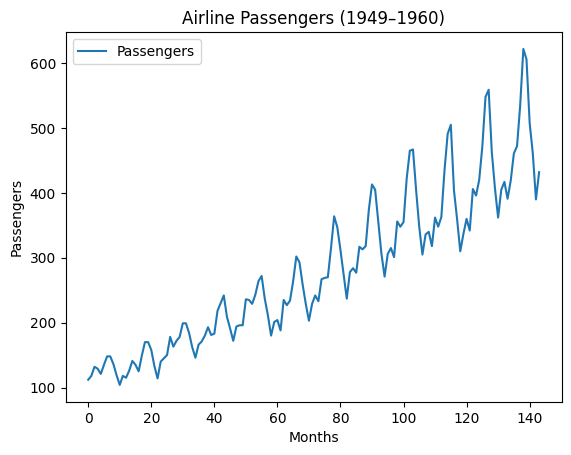

Training samples: 100 | Test samples: 44


In [ ]:
# Load dataset (only 2nd column)
data = pd.read_csv("airline-passengers.csv", usecols=[1], engine="python")

# Plot passengers over time
data.plot(title="Airline Passengers (1949–1960)")
plt.xlabel("Months")
plt.ylabel("Passengers")
plt.show()

# Convert to float32 numpy
data_np = data.to_numpy(dtype="float32")

# Train/test split (70/30)
split_idx = int(len(data_np) * 0.7)
train_np, test_np = data_np[:split_idx], data_np[split_idx:]

print(f"Training samples: {len(train_np)} | Test samples: {len(test_np)}")

# Scale using MinMaxScaler (fit on train, transform both)
scaler = sklearn.preprocessing.MinMaxScaler(feature_range=(0, 1))
train_np_norm, test_np_norm = scaler.fit_transform(train_np), scaler.transform(test_np)

First of all, you need to train an RNN on the airline passenger dataset. This exercise expects you to study the impact of the `window_size` variable when defining the `train` and `test` dataset splits. Remember that the `window_size` variable indicates the number of past observations used for predicting the current value. Here, we treat the `test` split as a validation set.

In [ ]:
def create_dataset(dataset, window_size = 1):
    data_x, data_y = [], []
    for i in range(len(dataset) - window_size):
        sample = dataset[i:(i + window_size), 0]
        data_x.append(sample)
        data_y.append(dataset[i + window_size, 0])
    return np.array(data_x), np.array(data_y)


window_size = 1 # Use this variable to build the dataset with different number of inputs

# Create test and training sets for regression with different window sizes.
train_X, train_Y = create_dataset(train_np_norm, window_size)
test_X, test_Y = create_dataset(test_np_norm, window_size)

train_X = np.reshape(train_X, (train_X.shape[0], train_X.shape[1], 1))
test_X = np.reshape(test_X, (test_X.shape[0], test_X.shape[1], 1))

# Convert to tensors
train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
train_Y_tensor = torch.tensor(train_Y, dtype=torch.float32).unsqueeze(1)
test_X_tensor = torch.tensor(test_X, dtype=torch.float32)
test_Y_tensor = torch.tensor(test_Y, dtype=torch.float32).unsqueeze(1)

print("Shape of training inputs: " + str((train_X_tensor.shape)))
print("Shape of training labels: " + str((train_Y_tensor.shape)))

Shape of training inputs: torch.Size([99, 1, 1])
Shape of training labels: torch.Size([99, 1])


Epoch [1/200] Train Loss: 0.1380
Epoch [2/200] Train Loss: 0.1149
Epoch [3/200] Train Loss: 0.0945
Epoch [4/200] Train Loss: 0.0778
Epoch [5/200] Train Loss: 0.0644
Epoch [6/200] Train Loss: 0.0551
Epoch [7/200] Train Loss: 0.0481
Epoch [8/200] Train Loss: 0.0440
Epoch [9/200] Train Loss: 0.0415
Epoch [10/200] Train Loss: 0.0404
Epoch [11/200] Train Loss: 0.0390
Epoch [12/200] Train Loss: 0.0380
Epoch [13/200] Train Loss: 0.0370
Epoch [14/200] Train Loss: 0.0358
Epoch [15/200] Train Loss: 0.0346
Epoch [16/200] Train Loss: 0.0335
Epoch [17/200] Train Loss: 0.0325
Epoch [18/200] Train Loss: 0.0309
Epoch [19/200] Train Loss: 0.0296
Epoch [20/200] Train Loss: 0.0282
Epoch [21/200] Train Loss: 0.0269
Epoch [22/200] Train Loss: 0.0253
Epoch [23/200] Train Loss: 0.0239
Epoch [24/200] Train Loss: 0.0225
Epoch [25/200] Train Loss: 0.0210
Epoch [26/200] Train Loss: 0.0196
Epoch [27/200] Train Loss: 0.0182
Epoch [28/200] Train Loss: 0.0167
Epoch [29/200] Train Loss: 0.0155
Epoch [30/200] Train Lo

/tmp/ipykernel_512/2674896540.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(X, dtype=torch.float32).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(Y, dtype=torch.float32).unsqueeze(1).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(X, dtype=torch.float32).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceT

Epoch [3/200] Train Loss: 0.0593
Epoch [4/200] Train Loss: 0.0445
Epoch [5/200] Train Loss: 0.0407
Epoch [6/200] Train Loss: 0.0394
Epoch [7/200] Train Loss: 0.0376
Epoch [8/200] Train Loss: 0.0357
Epoch [9/200] Train Loss: 0.0335
Epoch [10/200] Train Loss: 0.0314
Epoch [11/200] Train Loss: 0.0292
Epoch [12/200] Train Loss: 0.0271
Epoch [13/200] Train Loss: 0.0249
Epoch [14/200] Train Loss: 0.0224
Epoch [15/200] Train Loss: 0.0203
Epoch [16/200] Train Loss: 0.0183
Epoch [17/200] Train Loss: 0.0163
Epoch [18/200] Train Loss: 0.0152
Epoch [19/200] Train Loss: 0.0140
Epoch [20/200] Train Loss: 0.0132
Epoch [21/200] Train Loss: 0.0127
Epoch [22/200] Train Loss: 0.0115
Epoch [23/200] Train Loss: 0.0114
Epoch [24/200] Train Loss: 0.0113
Epoch [25/200] Train Loss: 0.0122
Epoch [26/200] Train Loss: 0.0118
Epoch [27/200] Train Loss: 0.0119
Epoch [28/200] Train Loss: 0.0113
Epoch [29/200] Train Loss: 0.0113
Epoch [30/200] Train Loss: 0.0110
Epoch [31/200] Train Loss: 0.0111
Epoch [32/200] Train 

/tmp/ipykernel_512/2674896540.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(X, dtype=torch.float32).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(Y, dtype=torch.float32).unsqueeze(1).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(X, dtype=torch.float32).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceT

Epoch [7/200] Train Loss: 0.0362
Epoch [8/200] Train Loss: 0.0334
Epoch [9/200] Train Loss: 0.0308
Epoch [10/200] Train Loss: 0.0277
Epoch [11/200] Train Loss: 0.0252
Epoch [12/200] Train Loss: 0.0222
Epoch [13/200] Train Loss: 0.0194
Epoch [14/200] Train Loss: 0.0172
Epoch [15/200] Train Loss: 0.0154
Epoch [16/200] Train Loss: 0.0144
Epoch [17/200] Train Loss: 0.0139
Epoch [18/200] Train Loss: 0.0139
Epoch [19/200] Train Loss: 0.0140
Epoch [20/200] Train Loss: 0.0145
Epoch [21/200] Train Loss: 0.0136
Epoch [22/200] Train Loss: 0.0132
Epoch [23/200] Train Loss: 0.0127
Epoch [24/200] Train Loss: 0.0129
Epoch [25/200] Train Loss: 0.0126
Epoch [26/200] Train Loss: 0.0130
Epoch [27/200] Train Loss: 0.0125
Epoch [28/200] Train Loss: 0.0125
Epoch [29/200] Train Loss: 0.0122
Epoch [30/200] Train Loss: 0.0121
Epoch [31/200] Train Loss: 0.0120
Epoch [32/200] Train Loss: 0.0120
Epoch [33/200] Train Loss: 0.0125
Epoch [34/200] Train Loss: 0.0120
Epoch [35/200] Train Loss: 0.0121
Epoch [36/200] Tr

/tmp/ipykernel_512/2674896540.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(X, dtype=torch.float32).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(Y, dtype=torch.float32).unsqueeze(1).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(X, dtype=torch.float32).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceT

Epoch [6/200] Train Loss: 0.0378
Epoch [7/200] Train Loss: 0.0358
Epoch [8/200] Train Loss: 0.0334
Epoch [9/200] Train Loss: 0.0314
Epoch [10/200] Train Loss: 0.0285
Epoch [11/200] Train Loss: 0.0252
Epoch [12/200] Train Loss: 0.0218
Epoch [13/200] Train Loss: 0.0181
Epoch [14/200] Train Loss: 0.0152
Epoch [15/200] Train Loss: 0.0137
Epoch [16/200] Train Loss: 0.0141
Epoch [17/200] Train Loss: 0.0129
Epoch [18/200] Train Loss: 0.0154
Epoch [19/200] Train Loss: 0.0128
Epoch [20/200] Train Loss: 0.0112
Epoch [21/200] Train Loss: 0.0113
Epoch [22/200] Train Loss: 0.0112
Epoch [23/200] Train Loss: 0.0108
Epoch [24/200] Train Loss: 0.0108
Epoch [25/200] Train Loss: 0.0107
Epoch [26/200] Train Loss: 0.0106
Epoch [27/200] Train Loss: 0.0106
Epoch [28/200] Train Loss: 0.0105
Epoch [29/200] Train Loss: 0.0104
Epoch [30/200] Train Loss: 0.0108
Epoch [31/200] Train Loss: 0.0107
Epoch [32/200] Train Loss: 0.0103
Epoch [33/200] Train Loss: 0.0102
Epoch [34/200] Train Loss: 0.0102
Epoch [35/200] Tra

/tmp/ipykernel_512/2674896540.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(X, dtype=torch.float32).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(Y, dtype=torch.float32).unsqueeze(1).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(X, dtype=torch.float32).to(DEVICE)
/tmp/ipykernel_512/2674896540.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceT

,window_size,train_rmse,test_rmse
0,1,23.216919,50.822800
1,3,22.280567,56.249143
2,6,21.901570,57.569536
3,12,17.683523,81.937268


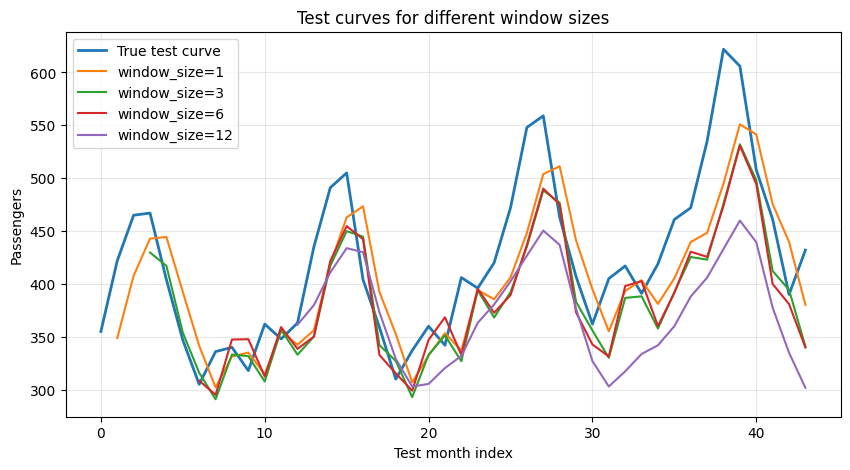

In [ ]:
# Coursework summary: Task 1 window_size sweep
window_sizes = [1, 3, 6, 12]
regression_coursework_results = []
regression_predictions = {}

for ws in window_sizes:
    set_seed(42)

    train_X, train_Y = create_dataset(train_np_norm, ws)
    test_X, test_Y = create_dataset(test_np_norm, ws)

    train_X = np.reshape(train_X, (train_X.shape[0], train_X.shape[1], 1))
    test_X = np.reshape(test_X, (test_X.shape[0], test_X.shape[1], 1))

    train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
    train_Y_tensor = torch.tensor(train_Y, dtype=torch.float32).unsqueeze(1)
    test_X_tensor = torch.tensor(test_X, dtype=torch.float32)
    test_Y_tensor = torch.tensor(test_Y, dtype=torch.float32).unsqueeze(1)

    train_loader_ws = DataLoader(TensorDataset(train_X_tensor, train_Y_tensor), batch_size=8, shuffle=True)

    model_ws = LSTMRegressor().to(DEVICE)
    train(
        model_ws,
        train_loader_ws,
        nn.MSELoss(),
        optim.Adam(model_ws.parameters(), lr=0.001),
        num_epochs=200,
    )

    train_rmse, _ = get_predict_and_score(model_ws, train_X_tensor, train_Y_tensor.squeeze(1), scaler)
    test_rmse, test_predict = get_predict_and_score(model_ws, test_X_tensor, test_Y_tensor.squeeze(1), scaler)

    regression_coursework_results.append({
        'window_size': ws,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
    })
    regression_predictions[ws] = test_predict.reshape(-1)

regression_coursework_df = pd.DataFrame(regression_coursework_results)
display(regression_coursework_df)

plt.figure(figsize=(10, 5))
true_test_curve = scaler.inverse_transform(test_np_norm).reshape(-1)
plt.plot(true_test_curve, label='True test curve', linewidth=2)
for ws, pred in regression_predictions.items():
    x_axis = np.arange(ws, ws + len(pred))
    plt.plot(x_axis, pred, label=f'window_size={ws}')
plt.xlabel('Test month index')
plt.ylabel('Passengers')
plt.title('Test curves for different window sizes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Report**:

*   Create a plot showing the test curves of models trained with different `window_size` values. Report the plot and discuss the main differences you observe between the predicted curves. You can use the style proposed on the Many to One RNNs - Regression section to plot your curves.

### **Task 2: Text Embeddings**
For this task, we tackle a classification problem using the IMDB sentiment dataset as done in the example in the notebook. Labels in IMDB are 0 for negative reviews and 1 for positive reviews. The definitions of the models you will use for this task are given the code below. This task is similar to the transfer learning/finetuning task in the CNN Architectures notebook, however we now test the effect of transfer learning in the embeddings. In this task we use train, validation and test splits with Early Stopping. That means that we will take the best performing model in the validation set and use it in the test set to get a final performance.

**Report**
* Using embeddings of dimensionality 1, train a model without using any LSTM, only using an average pooling of the input embeddings (called `embeddings_model` in the code given below). Then train another model with an LSTM and trainable embeddings initialized at random (called `lstm_model`). Finally train a model with an LSTM with non-trainable embeddings initialized with GloVe embeddings (called `lstm_glove_model`). The code to train the three models is given below. Report in a table the test accuracy obtained after training with the given code for the three models. Also attach in the Appendix the training and validation accuracy curves for the different models trained. You can report the curves after using EarlyStopping with patience 10 (already given in the code), so you don't have to train for the full 50 epochs the three models. Discuss the results.

* Predict the sentiment of the two given example reviews in the code below for the model trained without a LSTM (`embeddings_model`) and for the model trained with a LSTM and GloVe embeddings (`lstm_glove_model`). Report the predictions (you can use the same table as when reporting test accuracies). Discuss the results. Also discuss the differences you can observe between the GloVe embeddings and the embeddings learnt in `embeddings_model` (e.g. what kind of properties the embeddings encode, or differences in the closest words).


We provide the training code you need to use for this exercise below. First we load the dataset as we did in the tutorial. In this exercise, we will use of train, validation and test splits, which are defined in the next cell.


In [ ]:
# Parameters
nb_words = 5000
maxlen = 100

# Load IMDb dataset
dataset = load_dataset("imdb")

# Tokenizer
def tokenize(text):
    return nltk.word_tokenize(text.lower())

# Build vocabulary from training set
counter = Counter()
for text in dataset['train']['text']:
    counter.update(tokenize(text))

# Create word2idx with special tokens
most_common = counter.most_common(nb_words - 3)
word2idx = {'<PAD>': 0, '<START>': 1, '<UNK>': 2}
for idx, (word, _) in enumerate(most_common, start=3):
    word2idx[word] = idx

# Reverse index
idx2word = {idx: word for word, idx in word2idx.items()}

# Encode and pad a single text
def encode(text, maxlen=maxlen):
    tokens = tokenize(text)
    indices = [word2idx['<START>']] + [word2idx.get(t, word2idx['<UNK>']) for t in tokens]
    indices = indices[:maxlen]  # truncate if too long
    indices += [word2idx['<PAD>']] * (maxlen - len(indices))  # pad if too short
    return torch.tensor(indices, dtype=torch.long)

# Preprocess list of texts
def preprocess(text_list):
    return torch.stack([encode(text) for text in text_list])

# Process datasets
x_train_full = preprocess(dataset['train']['text'])
y_train_full = torch.tensor(dataset['train']['label'], dtype=torch.long)
x_test = preprocess(dataset['test']['text'])
y_test = torch.tensor(dataset['test']['label'], dtype=torch.long)

# Train/Val split
x_val = x_train_full[20000:]
y_val = y_train_full[20000:]
x_train = x_train_full[:20000]
y_train = y_train_full[:20000]

# Print shapes
print('x_train shape:', x_train.shape)
print('x_val shape:', x_val.shape)
print('x_test shape:', x_test.shape)

# Wrap in DataLoaders
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=32)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=32)

x_train shape: torch.Size([20000, 100])
x_val shape: torch.Size([5000, 100])
x_test shape: torch.Size([25000, 100])


In [ ]:
# Function implementing early stopping logic

def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    device,
    max_epochs=50,
    patience=10,
    reshape=False
):
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(max_epochs):
        # --- Training ---
        model.train()
        train_loss, train_correct, total = 0.0, 0, 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device).float()

            optimizer.zero_grad()
            outputs = model(x_batch)
            if reshape:
              loss = criterion(outputs, y_batch.unsqueeze(1).float())
            else:
              loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_batch.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).long()
            train_correct += (preds.view(-1) == y_batch.long()).sum().item()
            total += x_batch.size(0)

        avg_train_loss = train_loss / total
        train_acc = train_correct / total

        # --- Validation ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(device), y_val.to(device).float()
                outputs = model(x_val)
                if reshape:
                  loss = criterion(outputs, y_val.unsqueeze(1).float())
                else:
                  loss = criterion(outputs, y_val)

                val_loss += loss.item() * x_val.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).long()
                val_correct += (preds.view(-1) == y_val.long()).sum().item()
                val_total += x_val.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Save history
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}")

        # --- Early stopping logic ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print("  ↳ New best model saved")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Load best model
    model.load_state_dict(best_model_state)

    # --- Final test evaluation ---
    model.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0
    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device).float()
            outputs = model(x_test)
            if reshape:
              loss = criterion(outputs, y_test.unsqueeze(1).float())
            else:
              loss = criterion(outputs, y_test)

            test_loss += loss.item() * x_test.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).long()
            test_correct += (preds.view(-1) == y_test.long()).sum().item()
            test_total += x_test.size(0)

    final_test_loss = test_loss / test_total
    final_test_acc = test_correct / test_total

    print(f"Final Test Loss: {final_test_loss:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")

    return history, final_test_loss, final_test_acc, best_model_state

The following code includes the model that uses embeddings of size 1 (so each word is only represented by a single digit) and averages them.

In [ ]:
# Define the model
class EmbeddingsModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=1):
        super(EmbeddingsModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.global_avg_pool = lambda x: x.mean(dim=1)
        self.fc = nn.Linear(embedding_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)                     # [batch_size, maxlen, 1]
        x = self.global_avg_pool(x)               # [batch_size, 1]
        x = self.fc(x)                            # [batch_size, 1]
        return x

In [ ]:
set_seed(42)

# Instantiate model
embeddings_model = EmbeddingsModel(
    vocab_size=len(word2idx)
).to(DEVICE)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(embeddings_model.parameters(), lr=1e-3)

# Call the training function
embeddings_history, embeddings_test_loss, embeddings_test_acc, best_embeddings_model_state = train_with_early_stopping(
    model=embeddings_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    reshape=True
)

Epoch 1: Train Loss=0.6618, Train Acc=0.6219, Val Loss=0.9371, Val Acc=0.0382
  ↳ New best model saved
Epoch 2: Train Loss=0.6532, Train Acc=0.6242, Val Loss=0.9658, Val Acc=0.0420
  ↳ New best model saved
Epoch 3: Train Loss=0.6450, Train Acc=0.6255, Val Loss=0.9636, Val Acc=0.0548
  ↳ New best model saved
Epoch 4: Train Loss=0.6329, Train Acc=0.6295, Val Loss=0.9265, Val Acc=0.0962
  ↳ New best model saved
Epoch 5: Train Loss=0.6170, Train Acc=0.6443, Val Loss=0.9208, Val Acc=0.1548
  ↳ New best model saved
Epoch 6: Train Loss=0.5983, Train Acc=0.6669, Val Loss=0.8877, Val Acc=0.2442
  ↳ New best model saved
Epoch 7: Train Loss=0.5780, Train Acc=0.6914, Val Loss=0.8461, Val Acc=0.3330
  ↳ New best model saved
Epoch 8: Train Loss=0.5573, Train Acc=0.7160, Val Loss=0.8325, Val Acc=0.3872
  ↳ New best model saved
Epoch 9: Train Loss=0.5368, Train Acc=0.7352, Val Loss=0.7975, Val Acc=0.4452
  ↳ New best model saved
Epoch 10: Train Loss=0.5172, Train Acc=0.7519, Val Loss=0.7916, Val Acc=0

We use Early Stopping, so the best validation model is then used to compute the result in the test set.

Now we have `embedding_model` trained. The code below will print the embedding of any `query_word`, which in this case is a single number. We also give you the code to compute the `top_k` closest embeddings to `query_word`. The metric used is the L2 distance.

In [ ]:
def get_most_similar_words(best_model_state, model_class, parameters,
                           query, word2idx, idx2word, top_k=10, is_index=False):
    """
    query: can be a word (like 'cat') or an index (like 1 if is_index=True)
    """
    # Load model and set to eval mode
    model = model_class(**parameters)
    model.load_state_dict(best_model_state)
    model.eval()

    # Get embeddings
    embeddings = model.embedding.weight.data.cpu().numpy()

    # Handle query input
    if is_index:
        query_idx = int(query)
        query_word = idx2word.get(query_idx, "<UNK>")
    else:
        query_word = query
        if query_word not in word2idx:
            print(f"Word '{query_word}' not found in vocab.")
            return
        query_idx = word2idx[query_word]

    query_vector = embeddings[query_idx]

    # Compute L2 distances
    distances = ((embeddings - query_vector) ** 2).sum(axis=1)
    nearest_indices = distances.argsort()[1:top_k+1]

    print(f"Query index: {query_idx}")
    print(f"Query word: '{query_word}'")
    print(f"Embedding value of '{query_word}' is {query_vector[0]:.6f}")
    print(f"Most {top_k} similar words to '{query_word}':")
    for rank, idx in enumerate(nearest_indices, start=1):
        print(f"{rank}: {idx2word.get(idx, '<UNK>')}")

# Example usage
parameters = {
    "vocab_size": len(word2idx)
}

get_most_similar_words(
    best_model_state=best_embeddings_model_state,
    model_class=EmbeddingsModel,
    parameters=parameters,
    query='8',            # Query parameter
    word2idx=word2idx,
    idx2word=idx2word,
    top_k=10,
    is_index=False
)

Query index: 1206
Query word: '8'
Embedding value of '8' is 2.307665
Most 10 similar words to '8':
1: entertaining
2: trek
3: historical
4: exceptional
5: kudos
6: sadness
7: ages
8: othello
9: shop
10: sympathetic


The code below gives the prediction for two example reviews we input. Remember that predictions close to 0 refer to a negative review, and predictions close to 1 refer to a positive review.

In [ ]:
def predict_sentiment(text, model_class, best_model_state, word2idx, parameters, maxlen, device='cpu'):
    # Re-instantiate and load model
    model = model_class(**parameters)
    model.load_state_dict(best_model_state)
    model.to(device)
    model.eval()

    # Tokenize and encode
    tokens = text.lower().split()
    encoded = [word2idx.get('<START>', 1)] + [word2idx.get(w, word2idx['<UNK>']) for w in tokens]
    tensor = torch.tensor(encoded, dtype=torch.long).unsqueeze(0)  # batch of 1

    # Pad or truncate
    if tensor.size(1) < maxlen:
        pad_len = maxlen - tensor.size(1)
        tensor = F.pad(tensor, (0, pad_len), value=word2idx['<PAD>'])
    else:
        tensor = tensor[:, :maxlen]

    tensor = tensor.to(device)

    # Predict
    with torch.no_grad():
        output = model(tensor)
        prob = torch.sigmoid(output).item()
    return prob

In [ ]:
neg_review = "the movie is boring and not good"
pos_review = "the movie is good and not boring"

neg_score = predict_sentiment(
    text=neg_review,
    model_class=EmbeddingsModel,
    best_model_state=best_embeddings_model_state,
    word2idx=word2idx,
    parameters=parameters,
    maxlen=100
)

pos_score = predict_sentiment(
    text=pos_review,
    model_class=EmbeddingsModel,
    best_model_state=best_embeddings_model_state,
    word2idx=word2idx,
    parameters=parameters,
    maxlen=100
)

print(f"The score for the negative review is: {neg_score}")
print(f"The score for the positive review is: {pos_score}")

The score for the negative review is: 0.4842866361141205
The score for the positive review is: 0.4842866361141205


With the above code, we trained a model that classifies the sentiment of the sentence using the average of all the embeddings, which were only of size 1. Now we will increase the capacity of the embeddings to 300 and will also add a LSTM to process the embeddings. Hence, the model has a much higher capacity.

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, lstm_units=50, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        ### Do not modify the layers below
        self.dropout1 = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embedding_dim, lstm_units, batch_first=True, num_layers=2, dropout=dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_units, 1)

    def forward(self, x):
        x = self.embedding(x)                     # [batch_size, seq_len, embedding_dim]
        x = self.dropout1(x)
        output, (hidden, _) = self.lstm(x)        # hidden: [1, batch_size, lstm_units]
        x = self.dropout2(hidden[-1])             # Take the final hidden state
        x = self.fc(x)                            # [batch_size, 1]
        return x

Similarly, we use EarlyStopping for this model.

In [ ]:
set_seed(42)

# Instantiate model
lstm_model = LSTMModel(
    vocab_size=len(word2idx),
    embedding_dim=300,
    lstm_units=50
).to(DEVICE)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

# Call the training function
lstm_history, lstm_test_loss, lstm_test_acc, best_lstm_state = train_with_early_stopping(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    reshape=True
)

Epoch 1: Train Loss=0.6513, Train Acc=0.6229, Val Loss=0.7527, Val Acc=0.5420
  ↳ New best model saved
Epoch 2: Train Loss=0.6155, Train Acc=0.6633, Val Loss=0.8380, Val Acc=0.5046
Epoch 3: Train Loss=0.5582, Train Acc=0.7171, Val Loss=0.6212, Val Acc=0.7248
  ↳ New best model saved
Epoch 4: Train Loss=0.4982, Train Acc=0.7654, Val Loss=0.8442, Val Acc=0.5800
Epoch 5: Train Loss=0.4328, Train Acc=0.8051, Val Loss=0.7229, Val Acc=0.6798
Epoch 6: Train Loss=0.3742, Train Acc=0.8377, Val Loss=0.7949, Val Acc=0.6520
Epoch 7: Train Loss=0.3283, Train Acc=0.8585, Val Loss=0.7865, Val Acc=0.6990
Epoch 8: Train Loss=0.2930, Train Acc=0.8767, Val Loss=0.8121, Val Acc=0.6544
Epoch 9: Train Loss=0.2569, Train Acc=0.8968, Val Loss=0.9113, Val Acc=0.6460
Epoch 10: Train Loss=0.2255, Train Acc=0.9099, Val Loss=0.9827, Val Acc=0.6404
Epoch 11: Train Loss=0.1948, Train Acc=0.9251, Val Loss=0.9603, Val Acc=0.6940
Epoch 12: Train Loss=0.1724, Train Acc=0.9337, Val Loss=0.8676, Val Acc=0.7032
Epoch 13: T

In [ ]:
parameters = {
    "vocab_size": len(word2idx)
}

neg_review = "the movie is boring and not good"
pos_review = "the movie is good and not boring"

neg_score = predict_sentiment(
    text=neg_review,
    model_class=LSTMModel,
    best_model_state=best_lstm_state,
    word2idx=word2idx,
    parameters=parameters,
    maxlen=100
)

pos_score = predict_sentiment(
    text=pos_review,
    model_class=LSTMModel,
    best_model_state=best_lstm_state,
    word2idx=word2idx,
    parameters=parameters,
    maxlen=100
)

print(f"The score for the negative review is: {neg_score}")
print(f"The score for the positive review is: {pos_score}")

The score for the negative review is: 0.25202152132987976
The score for the positive review is: 0.24841929972171783


We just trained a model with a large number of parameters in the IMDB, which is a small dataset.

The last model we train is the same model as the `lstm_model` above, but in this case we use the embeddings from the GloVe method (which were introduced in this notebook) without any finetuning. First, we download them.

In [ ]:
!wget https://imperialcollegelondon.box.com/shared/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt -O glove_vectors.txt

--2026-03-06 03:26:22--  https://imperialcollegelondon.box.com/shared/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt
Resolving imperialcollegelondon.box.com (imperialcollegelondon.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to imperialcollegelondon.box.com (imperialcollegelondon.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt [following]
--2026-03-06 03:26:22--  https://imperialcollegelondon.box.com/public/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt
Reusing existing connection to imperialcollegelondon.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://imperialcollegelondon.app.box.com/public/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt [following]
--2026-03-06 03:26:22--  https://imperialcollegelondon.app.box.com/public/static/c9trfhhwl9ohje5g3sapu3xk2zoywp3c.txt
Resolving imperialcollegelondon.app.box.com (imperialc

Then we load the GloVe embeddings with dimensionality 300 we just downloaded. This takes some time.

In [ ]:
# Load GloVe vectors and build vocab and weight matrix
def load_glove(glove_path, embedding_dim):
    vocab = {}
    vectors = []
    skipped = 0

    with open(glove_path, "r", encoding="utf-8") as f:
        first_line = f.readline()
        if len(first_line.strip().split()) == 2:
            print(f"Skipping header: {first_line.strip()}")
        else:
            f.seek(0)

        for line in f:
            tokens = line.rstrip().split()
            word, values = tokens[0], tokens[1:]

            if len(values) != embedding_dim:
                skipped += 1
                continue

            try:
                vector = np.array(values, dtype=np.float32)
            except ValueError:
                skipped += 1
                continue

            vocab[word] = len(vectors)
            vectors.append(torch.from_numpy(vector))

    if not vectors:
        raise RuntimeError("No valid embeddings loaded. Check file format.")

    weight_matrix = torch.stack(vectors)
    print(f"Loaded {len(vectors)} word vectors. Skipped {skipped} lines.")
    return vocab, weight_matrix

# Example
glove_path = "glove_vectors.txt"
vocab, weight_matrix = load_glove(glove_path, embedding_dim=300)

Skipping header: 400000 300
Loaded 400000 word vectors. Skipped 0 lines.


In [ ]:
embedding_dim = 300
embedding_matrix = torch.zeros((nb_words, embedding_dim))

# Align GloVe vectors to our vocabulary
for word, idx in word2idx.items():
    if idx >= nb_words:
        continue  # Skip words beyond vocab limit
    if word in vocab:
        embedding_matrix[idx] = weight_matrix[vocab[word]]

To initialize the PyTorch Embedding layer with the embeddings we loaded, we can use the function `nn.Embedding.from_pretrained`. Also, to freeze the embeddings during training, we use `freeze=freeze`.

In [ ]:
class LSTMWithGloVe(nn.Module):
    def __init__(self, embedding_tensor, lstm_units=50, dropout=0.2, freeze=True):
        super(LSTMWithGloVe, self).__init__()

        # Define embedding layer from pretrained tensor
        self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze)

        self.dropout1 = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embedding_tensor.shape[1],  # Embedding dim
            hidden_size=lstm_units,
            batch_first=True,
            dropout=dropout,
            num_layers=2
        )
        self.dropout2 = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_units, 1)

    def forward(self, x):
        x = self.embedding(x)                     # [batch_size, seq_len, embedding_dim]
        x = self.dropout1(x)
        output, (hidden, _) = self.lstm(x)        # hidden: [1, batch_size, lstm_units]
        x = self.dropout2(hidden[-1])             # Final hidden state
        x = self.fc(x)                            # [batch_size, 1]
        return x

In [ ]:
set_seed(42)

# Instantiate model
lstm_glove_model = LSTMWithGloVe(
    embedding_tensor=embedding_matrix,
    lstm_units=50
).to(DEVICE)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(lstm_glove_model.parameters(), lr=1e-3)

# Call the training function
lstm_glove_history, lstm_glove_test_loss, lstm_glove_test_acc, best_lstm_glove_state = train_with_early_stopping(
    model=lstm_glove_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    reshape=True
)

Epoch 1: Train Loss=0.6335, Train Acc=0.6562, Val Loss=0.9617, Val Acc=0.0008
  ↳ New best model saved
Epoch 2: Train Loss=0.5745, Train Acc=0.7019, Val Loss=0.9331, Val Acc=0.4762
  ↳ New best model saved
Epoch 3: Train Loss=0.4598, Train Acc=0.7804, Val Loss=0.5183, Val Acc=0.8206
  ↳ New best model saved
Epoch 4: Train Loss=0.4275, Train Acc=0.7996, Val Loss=0.5893, Val Acc=0.7120
Epoch 5: Train Loss=0.4058, Train Acc=0.8105, Val Loss=0.6097, Val Acc=0.6680
Epoch 6: Train Loss=0.3905, Train Acc=0.8204, Val Loss=0.5167, Val Acc=0.7438
Epoch 7: Train Loss=0.3728, Train Acc=0.8287, Val Loss=0.5437, Val Acc=0.7332
Epoch 8: Train Loss=0.3626, Train Acc=0.8344, Val Loss=0.5179, Val Acc=0.7572
Epoch 9: Train Loss=0.3474, Train Acc=0.8439, Val Loss=0.5545, Val Acc=0.7474
Epoch 10: Train Loss=0.3340, Train Acc=0.8511, Val Loss=0.9342, Val Acc=0.4926
Epoch 11: Train Loss=0.3186, Train Acc=0.8610, Val Loss=0.6537, Val Acc=0.7002
Epoch 12: Train Loss=0.3006, Train Acc=0.8696, Val Loss=0.5297, V

We can also compute the closest words in the GloVe embeddings to any `query_word` using the code below.

In [ ]:
parameters = {
    "embedding_tensor": embedding_matrix
}

get_most_similar_words(
    best_model_state=best_lstm_glove_state,
    model_class=LSTMWithGloVe,
    parameters=parameters,
    query='8',              # Query parameter
    word2idx=word2idx,
    idx2word=idx2word,
    top_k=10,
    is_index=False
)

Query index: 1206
Query word: '8'
Embedding value of '8' is -0.245780
Most 10 similar words to '8':
1: 9
2: 7
3: 6
4: 5
5: 4
6: 12
7: 3
8: 10
9: 16
10: 13


We use the same example reviews as for the `EmbeddingsModel` case and we compute the predictions using the `LSTMWithGloVe`.

In [ ]:
neg_review = "the movie is boring and not good"
pos_review = "the movie is good and not boring"

neg_score = predict_sentiment(
    text=neg_review,
    model_class=LSTMWithGloVe,
    best_model_state=best_lstm_glove_state,
    word2idx=word2idx,
    parameters=parameters,
    maxlen=100
)

pos_score = predict_sentiment(
    text=pos_review,
    model_class=LSTMWithGloVe,
    best_model_state=best_lstm_glove_state,
    word2idx=word2idx,
    parameters=parameters,
    maxlen=100
)

print(f"The score for the negative review is: {neg_score}")
print(f"The score for the positive review is: {pos_score}")

The score for the negative review is: 0.3381562829017639
The score for the positive review is: 0.6616872549057007


,model,test_acc,neg_review_score,pos_review_score
0,embeddings_model,0.78004,0.484287,0.484287
1,lstm_model,0.73276,0.252022,0.248419
2,lstm_glove_model,0.78212,0.338156,0.661687


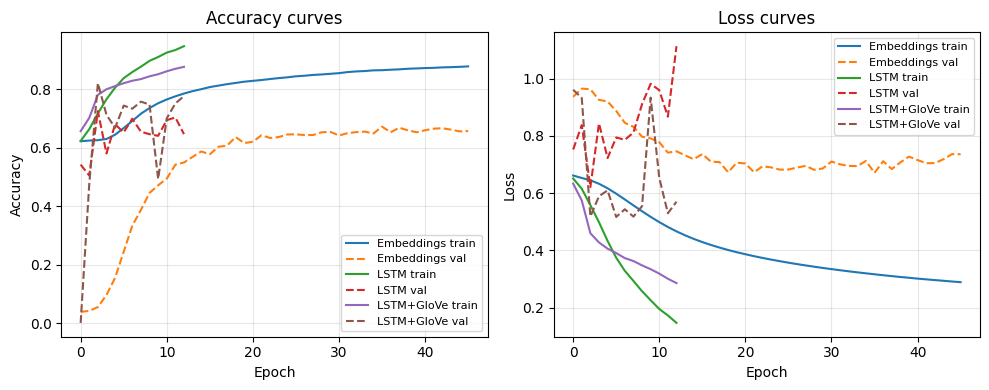

In [ ]:
# Coursework summary: Task 2 table and accuracy curves
embeddings_parameters = {"vocab_size": len(word2idx)}
glove_parameters = {"embedding_tensor": embedding_matrix}

neg_review = "the movie is boring and not good"
pos_review = "the movie is good and not boring"

summary_rows = [
    {
        'model': 'embeddings_model',
        'test_acc': embeddings_test_acc,
        'neg_review_score': predict_sentiment(neg_review, EmbeddingsModel, best_embeddings_model_state, word2idx, embeddings_parameters, maxlen=100),
        'pos_review_score': predict_sentiment(pos_review, EmbeddingsModel, best_embeddings_model_state, word2idx, embeddings_parameters, maxlen=100),
    },
    {
        'model': 'lstm_model',
        'test_acc': lstm_test_acc,
        'neg_review_score': predict_sentiment(neg_review, LSTMModel, best_lstm_state, word2idx, embeddings_parameters, maxlen=100),
        'pos_review_score': predict_sentiment(pos_review, LSTMModel, best_lstm_state, word2idx, embeddings_parameters, maxlen=100),
    },
    {
        'model': 'lstm_glove_model',
        'test_acc': lstm_glove_test_acc,
        'neg_review_score': predict_sentiment(neg_review, LSTMWithGloVe, best_lstm_glove_state, word2idx, glove_parameters, maxlen=100),
        'pos_review_score': predict_sentiment(pos_review, LSTMWithGloVe, best_lstm_glove_state, word2idx, glove_parameters, maxlen=100),
    },
]

rnn_task2_results = pd.DataFrame(summary_rows)
display(rnn_task2_results)

histories = {
    'Embeddings': embeddings_history,
    'LSTM': lstm_history,
    'LSTM+GloVe': lstm_glove_history,
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for name, hist in histories.items():
    axes[0].plot(hist['train_acc'], label=f'{name} train')
    axes[0].plot(hist['val_acc'], linestyle='--', label=f'{name} val')
    axes[1].plot(hist['train_loss'], label=f'{name} train')
    axes[1].plot(hist['val_loss'], linestyle='--', label=f'{name} val')

axes[0].set_title('Accuracy curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_title('Loss curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### **Task 3: Text Generation**
In this task we focus on the text generation problem. For this purpose, we will download the scripts of the TV show Game of Thrones and try to generate some text resembling the style of the scripts.


**Report**
* Plot the retrieved BLEU for different temperature values (from 0 to 2 in the x-axis) for both the character-level model and the word-level model. To compute the BLEU score, use a minimum of 20 generated samples per temperature used to reduce variability (you can increase it at the cost of higher computational time for lower variability). Each sample should contain 100 characters for the char-level model or 30 words for the word-level model (the code given uses these parameters by default). Do you see any relationship between the obtained BLEU score and temperature used? If you generate sentences at different temperatures what differences can you observe? Are the generated sentences grammatically correct? Do the generated sentences make sense?

We give below the code needed to download the dataset and to compute the results.

We first download and read the dataset.

In [ ]:
!git clone https://github.com/shekharkoirala/Game_of_Thrones

data = open('./Game_of_Thrones/Data/final_data.txt', 'r').read()

Cloning into 'Game_of_Thrones'...
remote: Enumerating objects: 145, done.
remote: Total 145 (delta 0), reused 0 (delta 0), pack-reused 145 (from 1)
Receiving objects: 100% (145/145), 1.82 MiB | 19.38 MiB/s, done.
Resolving deltas: 100% (40/40), done.


**Character-level model**

We first include the code to build the character-level dataset.

In [ ]:
# Vocabulary
characters = sorted(set(data))
n_to_char = {i: ch for i, ch in enumerate(characters)}
char_to_n = {ch: i for i, ch in enumerate(characters)}

# Sliding windows
seq_char_length = 100
x_char = np.array([
    [char_to_n[ch] for ch in data[i:i+seq_char_length]]
    for i in range(len(data) - seq_char_length)
], dtype=np.int64)

y_char = np.array([
    char_to_n[data[i+seq_char_length]]
    for i in range(len(data) - seq_char_length)
], dtype=np.int64)

print("Total Samples:", len(x_char))
print("x_char shape:", x_char.shape, "y_char shape:", y_char.shape)

Total Samples: 2474358
x_char shape: (2474358, 100) y_char shape: (2474358,)


The splits used for training are given below, although we already give the model trained.

In [ ]:
# Sizes
n_samples = len(x_char)
n_samples_train = int(n_samples * 0.7)
n_samples_test  = int(n_samples * 0.2)
n_samples_val   = n_samples - n_samples_train - n_samples_test

# Train/val/test splits
x_train_char = x_char[:n_samples_train]
y_train_char = y_char[:n_samples_train]

x_val_char   = x_char[n_samples_train:n_samples_train + n_samples_val]
y_val_char   = y_char[n_samples_train:n_samples_train + n_samples_val]

x_test_char  = x_char[n_samples_train + n_samples_val:]
y_test_char  = y_char[n_samples_train + n_samples_val:]

# Convert all to torch tensors in one go
to_tensor = lambda arr: torch.tensor(arr, dtype=torch.long)

x_train_char, y_train_char = map(to_tensor, (x_train_char, y_train_char))
x_val_char,   y_val_char   = map(to_tensor, (x_val_char, y_val_char))
x_test_char,  y_test_char  = map(to_tensor, (x_test_char, y_test_char))

print(f"x_train_char: {x_train_char.shape}, y_train_char: {y_train_char.shape}")
print(f"x_val_char:   {x_val_char.shape},   y_val_char:   {y_val_char.shape}")
print(f"x_test_char:  {x_test_char.shape},  y_test_char:  {y_test_char.shape}")

x_train_char: torch.Size([1732050, 100]), y_train_char: torch.Size([1732050])
x_val_char:   torch.Size([247437, 100]),   y_val_char:   torch.Size([247437])
x_test_char:  torch.Size([494871, 100]),  y_test_char:  torch.Size([494871])


The definition of the model is the one given below. You will not train the model, so this piece of code is only for you to know what kind of model we trained for this task.

In [ ]:
# define the LSTM model
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_size=300, lstm_units=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.lstm = nn.LSTM(embedding_size, lstm_units, batch_first=True)
        self.fc = nn.Linear(lstm_units, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)                 # (B, T, E)
        out, _ = self.lstm(emb)                 # (B, T, H)
        last = out[:, -1, :]                    # (B, H)  last time step
        logits = self.fc(last)                  # (B, V)
        return logits                           # raw logits

As the training takes a while, we include a saved model that you can load to skip the training step. Use this model to compute your results.

In [ ]:
'''
CODE USED FOR TRAINING (DO NOT RUN IT!)

from google.colab import files

# ---- config ----
batch_size = 128
epochs = 100
patience = 10
lr = 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vocab_size = len(characters)
model = CharLSTM(vocab_size=vocab_size, embedding_size=300, lstm_units=256).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# ---- data loaders (labels are integer class ids) ----
train_ds = TensorDataset(x_train_char, y_train_char)
val_ds   = TensorDataset(x_val_char,   y_val_char)
test_ds  = TensorDataset(x_test_char,  y_test_char)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)

# ---- early stopping ----
class EarlyStopping:
    def __init__(self, patience=10, mode='max', min_delta=0.0, restore_best=True):
        self.patience = patience
        self.mode = mode  # 'max' for accuracy
        self.min_delta = min_delta
        self.restore_best = restore_best
        self.best_score = None
        self.counter = 0
        self.best_state = None
        self.best_epoch = 0

    def step(self, score, model, epoch):
        improve = False
        if self.best_score is None:
            improve = True
        else:
            if self.mode == 'max':
                improve = score > (self.best_score + self.min_delta)
            else:
                improve = score < (self.best_score - self.min_delta)

        if improve:
            self.best_score = score
            self.counter = 0
            if self.restore_best:
                self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            self.best_epoch = epoch
            return False
        else:
            self.counter += 1
            return self.counter > self.patience  # stop if patience exceeded

    def restore(self, model):
        if self.restore_best and self.best_state is not None:
            model.load_state_dict(self.best_state)

early_stop = EarlyStopping(patience=patience, mode='max', min_delta=0.0, restore_best=True)

# ---- history ----
history = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': []
}

def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

# ---- training loop ----
best_path = 'char_gen_model.pth'
for epoch in range(1, epochs + 1):
    # train
    model.train()
    epoch_loss = 0.0
    epoch_acc = 0.0
    n_batches = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)            # [B, V]
        loss = criterion(logits, yb)  # yb: [B] integer targets
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc  += accuracy_from_logits(logits, yb)
        n_batches  += 1

    train_loss = epoch_loss / n_batches
    train_acc  = epoch_acc  / n_batches

    # validate
    model.eval()
    val_loss = 0.0
    val_acc  = 0.0
    n_val    = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            val_acc  += accuracy_from_logits(logits, yb)
            n_val    += 1

    val_loss /= max(1, n_val)
    val_acc  /= max(1, n_val)

    # record history
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch:3d}/{epochs}  "
          f"loss={train_loss:.4f}  acc={train_acc:.4f}  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

    # early stopping on val_accuracy
    stop = early_stop.step(val_acc, model, epoch)

    # save best
    if early_stop.best_state is not None and early_stop.best_epoch == epoch:
        torch.save(early_stop.best_state, best_path)

    if stop:
        print(f"Early stopping at epoch {epoch}. Restoring best epoch {early_stop.best_epoch}...")
        break

# restore best weights
early_stop.restore(model)
torch.save(model.state_dict(), best_path)

# ---- test evaluation ----
model.eval()
test_loss = 0.0
test_acc = 0.0
n_test = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        test_loss += loss.item()
        test_acc  += accuracy_from_logits(logits, yb)
        n_test    += 1

test_loss /= max(1, n_test)
test_acc  /= max(1, n_test)

print(f"\nFinal test loss is: {test_loss:.4f}")
print(f"Final test accuracy is: {test_acc:.4f}")
print(f"Best model saved to: {best_path}")
files.download(best_path)
'''

'\nCODE USED FOR TRAINING (DO NOT RUN IT!)\n\nfrom google.colab import files\n\n# ---- config ----\nbatch_size = 128\nepochs = 100\npatience = 10\nlr = 1e-3\ndevice = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\n\nvocab_size = len(characters)\nmodel = CharLSTM(vocab_size=vocab_size, embedding_size=300, lstm_units=256).to(device)\ncriterion = nn.CrossEntropyLoss()\noptimizer = torch.optim.Adam(model.parameters(), lr=lr)\n\n# ---- data loaders (labels are integer class ids) ----\ntrain_ds = TensorDataset(x_train_char, y_train_char)\nval_ds   = TensorDataset(x_val_char,   y_val_char)\ntest_ds  = TensorDataset(x_test_char,  y_test_char)\n\ntrain_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)\nval_loader   = DataLoader(val_ds,   batch_size=batch_size)\ntest_loader  = DataLoader(test_ds,  batch_size=batch_size)\n\n# ---- early stopping ----\nclass EarlyStopping:\n    def __init__(self, patience=10, mode=\'max\', min_delta=0.0, restore_best=True):\n   

In [ ]:
# Load the model
!wget 'https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/05_RNN/char_gen_model.pth' -O char_gen_model.pth

vocab_size = len(characters)
model = CharLSTM(vocab_size=vocab_size, embedding_size=300, lstm_units=256).to(DEVICE)
model.load_state_dict(torch.load("char_gen_model.pth", map_location=DEVICE))

--2026-03-06 03:28:32--  https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/05_RNN/char_gen_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2501896 (2.4M) [application/octet-stream]
Saving to: ‘char_gen_model.pth’

char_gen_model.pth  100%[===================>]   2.39M  --.-KB/s    in 0.06s   

2026-03-06 03:28:32 (37.3 MB/s) - ‘char_gen_model.pth’ saved [2501896/2501896]



<All keys matched successfully>

The code you need to evaluate the BLEU score is given below. Vary the temperature to the different needed values. It takes around 1 minute in average per temperature if `n_eval` is set to 20.

In [ ]:
characters = sorted(list(set(data)))
n_to_char = {n: char for n, char in enumerate(characters)}
char_to_n = {char: n for n, char in enumerate(characters)}

# Vary the temperature here
temperature = 0.5
n_eval = 20
seq_char_length = 100
smoother = SmoothingFunction().method1
bleu_score = 0.0

model.eval()

with torch.no_grad():
  for _ in range(n_eval):
      # Randomly select a starting point in the test data
      start = np.random.randint(0, len(x_test_char) - seq_char_length - 1)
      pattern = x_test_char[start].tolist()
      reference = x_test_char[start + seq_char_length].tolist()

      # Convert reference from numbers to characters
      reference = ''.join([n_to_char[value] for value in reference])

      # Generate characters using the model
      output_sent = ''
      for _n in range(seq_char_length):
          x = torch.tensor(pattern, dtype=torch.long, device=DEVICE).unsqueeze(0)
          logits = model(x)
          temp = float(temperature) + 0.01
          probs = F.softmax((logits + 1e-7) / temp, dim=-1)
          idx = torch.multinomial(probs[0], num_samples=1).item()
          output_sent += n_to_char[idx]
          pattern.append(idx)
          pattern = pattern[1:]

      # Preprocess reference and candidate text
      reference = word_tokenize(reference.lower())
      candidate = word_tokenize(output_sent.lower())
      reference = list(filter(lambda x: x != '', reference))
      candidate = list(filter(lambda x: x != '', candidate))

      # Remove incomplete words at the beginning and end of both lists
      if len(reference) > 2:
          reference = reference[1:-1]
      if len(candidate) > 2:
          candidate = candidate[1:-1]

      # Compute BLEU score
      bleu_score += sentence_bleu([reference], candidate, smoothing_function=smoother)

bleu_score /= n_eval
print("BLEU Score:", bleu_score)

BLEU Score: 0.012791980798899696


The code below allows you to generate sentences for different input patterns and different temperature values. You can test how the temperature values affect the quality of the output sentences for the character-level model by generating a few examples.

In [ ]:
# Change the temperature here
temperature = 0.7
seed_text = "TYRION pours himself some wine and drinks it down. He pours another glass, and walks back to CERSEI "
pattern = [char_to_n[ch] for ch in seed_text[:seq_char_length]]

print("\nPredicted:")
model.eval()

with torch.no_grad():
    for _ in range(300):
        x = torch.tensor(pattern, dtype=torch.long, device=DEVICE).unsqueeze(0)
        logits = model(x)

        if temperature == 0:
            idx = torch.argmax(logits, dim=-1).item()
        else:
            probs = F.softmax(logits / temperature, dim=-1)
            idx = torch.multinomial(probs, num_samples=1).item()

        ch = n_to_char[idx]
        sys.stdout.write(ch)
        sys.stdout.flush()

        pattern = pattern[1:] + [idx]


Predicted:
on the stomach embers the flooring TALON with the stalt are the fire.
CERSEI: (summon to his head]
THOROS: [LOWD TENNE and TOMMEN begins write it while BRAN is the flame, and tracks up a sea and has every things as a knife falls and the second raises his mountage.
CUT TO: King Robert Baratheon, and 

**Word-level model**

We now give the code to run the word-level model. The code is similar to the char-level model. The main difference is that we only try to predict the 2000 words most commonly used in the dataset. The reason for this limitation is to limit the size of the output layer and number of input embeddings for memory constraints.

In [ ]:
n_words = 2000
seq_length = 30

# Preprocess text: lowercase + space around punctuation
data_p = (
    data.replace('.', ' . ').replace(',', ' , ').replace(':', ' : ')
        .replace('?', ' ? ').replace('!', ' ! ')
        .replace('\n', ' \n ').replace('[', ' [ ').replace(']', ' ] ')
        .replace(')', ' ) ').replace('(', ' ( ').lower().split()
)
data_p = [tok for tok in data_p if tok.strip()]

# Build vocab (most common words)
common = [w for w, _ in Counter(data_p).most_common(n_words)]
word_to_n = {w: i for i, w in enumerate(common)}
n_to_word = {i: w for i, w in enumerate(common)}
OOV_IDX = len(word_to_n)

# Build dataset
x_word, y_word = [], []
for i in range(len(data_p) - seq_length):
    seq = [word_to_n.get(w, OOV_IDX) for w in data_p[i:i+seq_length]]
    label = data_p[i + seq_length]
    if label in word_to_n:  # only predict in-vocab words
        x_word.append(seq)
        y_word.append(word_to_n[label])

n_samples = len(x_word)
print("Total Samples:", n_samples)

Total Samples: 511066


In [ ]:
n_samples = len(x_word)
n_samples_train = int(n_samples * 0.7)
n_samples_test  = int(n_samples * 0.2)
n_samples_val   = n_samples - n_samples_train - n_samples_test

# Train / val / test splits
x_train_word = x_word[:n_samples_train]
y_train_word = y_word[:n_samples_train]

x_val_word   = x_word[n_samples_train:n_samples_train+n_samples_val]
y_val_word   = y_word[n_samples_train:n_samples_train+n_samples_val]

x_test_word  = x_word[n_samples_train+n_samples_val:]
y_test_word  = y_word[n_samples_train+n_samples_val:]

# Convert labels to numpy first
y_train_word = np.array(y_train_word)
y_val_word   = np.array(y_val_word)
y_test_word  = np.array(y_test_word)

# Convert all to tensors
x_train_word = torch.tensor(x_train_word, dtype=torch.long)
x_val_word   = torch.tensor(x_val_word,   dtype=torch.long)
x_test_word  = torch.tensor(x_test_word,  dtype=torch.long)

y_train_word = torch.tensor(y_train_word, dtype=torch.long)
y_val_word   = torch.tensor(y_val_word,   dtype=torch.long)
y_test_word  = torch.tensor(y_test_word,  dtype=torch.long)

# Shapes
print(f"x_train_word: {x_train_word.shape}, y_train_word: {y_train_word.shape}")
print(f"x_val_word:   {x_val_word.shape},   y_val_word:   {y_val_word.shape}")
print(f"x_test_word:  {x_test_word.shape},  y_test_word:  {y_test_word.shape}")

x_train_word: torch.Size([357746, 30]), y_train_word: torch.Size([357746])
x_val_word:   torch.Size([51107, 30]),   y_val_word:   torch.Size([51107])
x_test_word:  torch.Size([102213, 30]),  y_test_word:  torch.Size([102213])


The definition of the word-level model we train is given below. The model is the same as in the char-level case, the only difference is the size of the output vector and the number of input embeddings.

In [ ]:
# define the LSTM model
class WordLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_size=300, lstm_units=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size)
        self.lstm = nn.LSTM(embedding_size, lstm_units, batch_first=True)
        self.fc = nn.Linear(lstm_units, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)           # (B, T, E)
        out, _ = self.lstm(emb)           # (B, T, H)
        last = out[:, -1, :]              # (B, H) last timestep
        logits = self.fc(last)            # (B, V)
        return logits                     # raw logits

As with the character-level model, training the word-level model takes a while. Use the saved model we included to compute your results.

In [ ]:
'''
CODE USED FOR TRAINING (DO NOT RUN IT!)

from google.colab import files

# ---- config ----
batch_size = 128
epochs = 100
patience = 10
lr = 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vocab_size = n_words + 1
model = WordLSTM(vocab_size=vocab_size, embedding_size=300, lstm_units=256).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# ---- data loaders (labels are integer class ids) ----
train_ds = TensorDataset(x_train_word, y_train_word)
val_ds   = TensorDataset(x_val_word,   y_val_word)
test_ds  = TensorDataset(x_test_word,  y_test_word)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)

# ---- early stopping ----
class EarlyStopping:
    def __init__(self, patience=10, mode='max', min_delta=0.0, restore_best=True):
        self.patience = patience
        self.mode = mode  # 'max' for accuracy
        self.min_delta = min_delta
        self.restore_best = restore_best
        self.best_score = None
        self.counter = 0
        self.best_state = None
        self.best_epoch = 0

    def step(self, score, model, epoch):
        improve = False
        if self.best_score is None:
            improve = True
        else:
            if self.mode == 'max':
                improve = score > (self.best_score + self.min_delta)
            else:
                improve = score < (self.best_score - self.min_delta)

        if improve:
            self.best_score = score
            self.counter = 0
            if self.restore_best:
                self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            self.best_epoch = epoch
            return False
        else:
            self.counter += 1
            return self.counter > self.patience  # stop if patience exceeded

    def restore(self, model):
        if self.restore_best and self.best_state is not None:
            model.load_state_dict(self.best_state)

early_stop = EarlyStopping(patience=patience, mode='max', min_delta=0.0, restore_best=True)

# ---- history ----
history = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': []
}

def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

# ---- training loop ----
best_path = 'word_gen_model.pth'
for epoch in range(1, epochs + 1):
    # train
    model.train()
    epoch_loss = 0.0
    epoch_acc = 0.0
    n_batches = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)            # [B, V]
        loss = criterion(logits, yb)  # yb: [B] integer targets
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc  += accuracy_from_logits(logits, yb)
        n_batches  += 1

    train_loss = epoch_loss / n_batches
    train_acc  = epoch_acc  / n_batches

    # validate
    model.eval()
    val_loss = 0.0
    val_acc  = 0.0
    n_val    = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            val_acc  += accuracy_from_logits(logits, yb)
            n_val    += 1

    val_loss /= max(1, n_val)
    val_acc  /= max(1, n_val)

    # record history
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch:3d}/{epochs}  "
          f"loss={train_loss:.4f}  acc={train_acc:.4f}  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

    # early stopping on val_accuracy
    stop = early_stop.step(val_acc, model, epoch)
    if early_stop.best_state is not None and early_stop.best_epoch == epoch:
        torch.save(early_stop.best_state, best_path)

    if stop:
        print(f"Early stopping at epoch {epoch}. Restoring best epoch {early_stop.best_epoch}...")
        break

# restore best weights
early_stop.restore(model)
torch.save(model.state_dict(), best_path)

# ---- test evaluation ----
model.eval()
test_loss = 0.0
test_acc = 0.0
n_test = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        test_loss += loss.item()
        test_acc  += accuracy_from_logits(logits, yb)
        n_test    += 1

test_loss /= max(1, n_test)
test_acc  /= max(1, n_test)

print(f"\nFinal test loss is: {test_loss:.4f}")
print(f"Final test accuracy is: {test_acc:.4f}")
print(f"Best model saved to: {best_path}")
files.download(best_path)
'''

'\nCODE USED FOR TRAINING (DO NOT RUN IT!)\n\nfrom google.colab import files\n\n# ---- config ----\nbatch_size = 128\nepochs = 100\npatience = 10\nlr = 1e-3\ndevice = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\n\nvocab_size = n_words + 1\nmodel = WordLSTM(vocab_size=vocab_size, embedding_size=300, lstm_units=256).to(device)\ncriterion = nn.CrossEntropyLoss()\noptimizer = torch.optim.Adam(model.parameters(), lr=lr)\n\n# ---- data loaders (labels are integer class ids) ----\ntrain_ds = TensorDataset(x_train_word, y_train_word)\nval_ds   = TensorDataset(x_val_word,   y_val_word)\ntest_ds  = TensorDataset(x_test_word,  y_test_word)\n\ntrain_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)\nval_loader   = DataLoader(val_ds,   batch_size=batch_size)\ntest_loader  = DataLoader(test_ds,  batch_size=batch_size)\n\n# ---- early stopping ----\nclass EarlyStopping:\n    def __init__(self, patience=10, mode=\'max\', min_delta=0.0, restore_best=True):\n       

In [ ]:
# Load the model
!wget 'https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/05_RNN/word_gen_model.pth' -O word_gen_model.pth

vocab_size = n_words + 1
model = WordLSTM(vocab_size=vocab_size, embedding_size=300, lstm_units=256).to(DEVICE)
model.load_state_dict(torch.load("word_gen_model.pth", map_location=DEVICE))

--2026-03-06 03:28:41--  https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/05_RNN/word_gen_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6746659 (6.4M) [application/octet-stream]
Saving to: ‘word_gen_model.pth’

word_gen_model.pth  100%[===================>]   6.43M  --.-KB/s    in 0.08s   

2026-03-06 03:28:41 (81.7 MB/s) - ‘word_gen_model.pth’ saved [6746659/6746659]



<All keys matched successfully>

In [ ]:
# Vary the temperature here
temperature = 0.7
n_eval = 20
seq_char_length = 100
smoother = SmoothingFunction().method1
bleu_score = 0.0

model.eval()

with torch.no_grad():
  for _ in range(n_eval):
      # We look for references that do not contain any non-common words as we only
      # learnt to predict the 2000 most common words
      while True:
          start = np.random.randint(0, len(x_test_word)-seq_length-1)
          pattern = x_test_word[start].tolist()
          reference = x_test_word[start+seq_length].tolist()
          if n_words not in reference:
              break
      reference = ' '.join([n_to_word[value] for value in reference])

      # generate words
      output_sent = ''
      for i in range(seq_length):
          x = torch.tensor(pattern, dtype=torch.long, device=DEVICE).unsqueeze(0)
          logits = model(x)
          probs = F.softmax((logits + 1e-7) / (float(temperature) + 0.01), dim=-1)
          idx = torch.multinomial(probs[0], num_samples=1).item()

          word = n_to_word.get(idx, '')
          output_sent += word + ' '

          pattern.append(idx)
          pattern = pattern[1:]

      # Preprocess reference and candidate text
      reference = word_tokenize(reference.lower())
      candidate = word_tokenize(output_sent.lower())

      # Remove empty strings (if any) after tokenization
      reference = list(filter(lambda x: x != '', reference))
      candidate = list(filter(lambda x: x != '', candidate))

      # Remove incomplete words at the beginning and end of both lists
      if len(reference) > 2:
          reference = reference[1:-1]
      if len(candidate) > 2:
          candidate = candidate[1:-1]

      # Compute BLEU score for the candidate and reference
      bleu_score += sentence_bleu([reference], candidate, smoothing_function=smoother)

bleu_score /= n_eval
print("BLEU Score:", bleu_score)

BLEU Score: 0.010957463740041171


,temperature,char_bleu,word_bleu
0,0.00,0.014413,0.011621
1,0.25,0.014075,0.012198
2,0.50,0.017702,0.011106
3,0.75,0.013561,0.010940
4,1.00,0.013263,0.011458
5,1.50,0.012280,0.008828
6,2.00,0.011486,0.007819


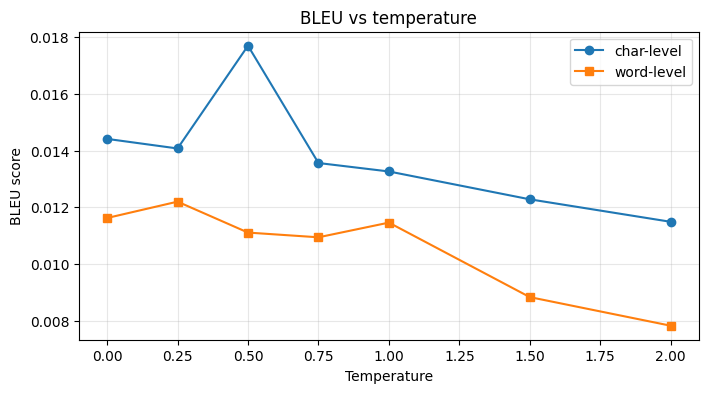

In [ ]:
# Coursework summary: BLEU vs temperature for character-level and word-level models
from pathlib import Path
from urllib.request import urlretrieve

def ensure_file(url, path):
    path = Path(path)
    if not path.exists():
        urlretrieve(url, path)
    return path


def evaluate_char_bleu(model, temperature, n_eval=20, seq_char_length=100):
    smoother = SmoothingFunction().method1
    bleu_score = 0.0
    model.eval()
    with torch.no_grad():
        for _ in range(n_eval):
            start = np.random.randint(0, len(x_test_char) - seq_char_length - 1)
            pattern = x_test_char[start].tolist()
            reference = x_test_char[start + seq_char_length].tolist()
            reference = ''.join([n_to_char[value] for value in reference])

            output_sent = ''
            for _ in range(seq_char_length):
                x = torch.tensor(pattern, dtype=torch.long, device=DEVICE).unsqueeze(0)
                logits = model(x)
                if temperature == 0:
                    idx = torch.argmax(logits, dim=-1).item()
                else:
                    probs = F.softmax((logits + 1e-7) / (float(temperature) + 0.01), dim=-1)
                    idx = torch.multinomial(probs[0], num_samples=1).item()
                output_sent += n_to_char[idx]
                pattern.append(idx)
                pattern = pattern[1:]

            reference_tokens = list(filter(lambda x: x != '', word_tokenize(reference.lower())))
            candidate_tokens = list(filter(lambda x: x != '', word_tokenize(output_sent.lower())))
            if len(reference_tokens) > 2:
                reference_tokens = reference_tokens[1:-1]
            if len(candidate_tokens) > 2:
                candidate_tokens = candidate_tokens[1:-1]
            bleu_score += sentence_bleu([reference_tokens], candidate_tokens, smoothing_function=smoother)
    return bleu_score / n_eval


def evaluate_word_bleu(model, temperature, n_eval=20):
    smoother = SmoothingFunction().method1
    bleu_score = 0.0
    model.eval()
    with torch.no_grad():
        for _ in range(n_eval):
            while True:
                start = np.random.randint(0, len(x_test_word) - seq_length - 1)
                pattern = x_test_word[start].tolist()
                reference = x_test_word[start + seq_length].tolist()
                if n_words not in reference:
                    break
            reference = ' '.join([n_to_word[value] for value in reference])

            output_sent = ''
            for _ in range(seq_length):
                x = torch.tensor(pattern, dtype=torch.long, device=DEVICE).unsqueeze(0)
                logits = model(x)
                if temperature == 0:
                    idx = torch.argmax(logits, dim=-1).item()
                else:
                    probs = F.softmax((logits + 1e-7) / (float(temperature) + 0.01), dim=-1)
                    idx = torch.multinomial(probs[0], num_samples=1).item()
                output_sent += n_to_word.get(idx, '') + ' '
                pattern.append(idx)
                pattern = pattern[1:]

            reference_tokens = list(filter(lambda x: x != '', word_tokenize(reference.lower())))
            candidate_tokens = list(filter(lambda x: x != '', word_tokenize(output_sent.lower())))
            if len(reference_tokens) > 2:
                reference_tokens = reference_tokens[1:-1]
            if len(candidate_tokens) > 2:
                candidate_tokens = candidate_tokens[1:-1]
            bleu_score += sentence_bleu([reference_tokens], candidate_tokens, smoothing_function=smoother)
    return bleu_score / n_eval


ensure_file('https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/05_RNN/char_gen_model.pth', 'char_gen_model.pth')
ensure_file('https://raw.githubusercontent.com/MatchLab-Imperial/deep-learning-course/master/asset/05_RNN/word_gen_model.pth', 'word_gen_model.pth')

char_model = CharLSTM(vocab_size=len(characters), embedding_size=300, lstm_units=256).to(DEVICE)
char_model.load_state_dict(torch.load('char_gen_model.pth', map_location=DEVICE))
word_model = WordLSTM(vocab_size=n_words + 1, embedding_size=300, lstm_units=256).to(DEVICE)
word_model.load_state_dict(torch.load('word_gen_model.pth', map_location=DEVICE))

temperatures = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
char_bleu_scores = [evaluate_char_bleu(char_model, t) for t in temperatures]
word_bleu_scores = [evaluate_word_bleu(word_model, t) for t in temperatures]

bleu_summary_df = pd.DataFrame({
    'temperature': temperatures,
    'char_bleu': char_bleu_scores,
    'word_bleu': word_bleu_scores,
})
display(bleu_summary_df)

plt.figure(figsize=(8, 4))
plt.plot(temperatures, char_bleu_scores, marker='o', label='char-level')
plt.plot(temperatures, word_bleu_scores, marker='s', label='word-level')
plt.xlabel('Temperature')
plt.ylabel('BLEU score')
plt.title('BLEU vs temperature')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Vary the temperature here
temperature = 0.7
seed_text = (
    "TYRION pours himself some wine and drinks it down. He pours another glass, "
    "and walks back to CERSEI placing his cup on her desk. He takes another glass.\n"
    "TYRION: "
)

# Preprocess seed
pattern = (
    seed_text.replace('.', ' . ').replace(',', ' , ').replace(':', ' : ')
    .replace('?', ' ? ').replace('!', ' ! ')
    .replace('\n', ' \n ').replace('[', ' [ ').replace(']', ' ] ')
    .replace(')', ' ) ').replace('(', ' ( ')
    .lower()
    .split()
)
pattern = [w for w in pattern if w.strip()][:seq_length]
print("\nInput Pattern:\n", " ".join(pattern))

# Map to indices (OOV → n_words)
pattern = [word_to_n.get(w, n_words) for w in pattern]

print("\nPredicted:")
model.eval()
with torch.no_grad():
    for _ in range(100):
        x = torch.tensor(pattern, dtype=torch.long, device=DEVICE).unsqueeze(0)
        logits = model(x)

        if temperature == 0:
            idx = torch.argmax(logits, dim=-1).item()
        else:
            probs = F.softmax(logits / temperature, dim=-1)
            idx = torch.multinomial(probs, num_samples=1).item()

        word = n_to_word.get(idx, "<UNK>")
        sys.stdout.write(word + " ")
        sys.stdout.flush()

        # Update pattern
        pattern = pattern[1:] + [idx]


Input Pattern:
 tyrion pours himself some wine and drinks it down . he pours another glass , and walks back to cersei placing his cup on her desk . he takes another

Predicted:
to i stay dothraki i up brienne look i can't never same you tent for . : more the as . : missandei back the your but his lancel . : some the and when those her . : takes the fire don't in his better to ? are i chance . : , up didn't we ought . : all the daario to his don't to jaime we i any rhaegar . : falls the , broke it mine . : years the ? are i landing sparrow you deal about pay . : bran she's the , mance 